# Adversarial Attacks on Class-Imbalanced Lending-Default Models

*Do resampling strategies harden or weaken class-imbalanced credit-risk models against adversarial attacks?*

**Course:** AAIB, University of Twente · **Authors:** Tim Angevare · Roy Mulder · Ruben Stevenaar · Rick Hezeman · **Date:** 03/07/2026


## Abstract

Credit default models are often trained on strongly imbalanced data, while they are also used in a setting where rejected applicants may have an incentive to change controllable information. This study examines whether resampling methods used to address class imbalance also affect the robustness of credit default models against such manipulation. Using the LendingClub accepted loans dataset, consisting of about 1.35 million paid or charged off loans and 24 selected features, four classifiers are trained: XGBoost, logistic regression, random forest, and a neural network. Each model is tested across five minority class ratios, ranging from 1% to 20%, and five resampling strategies. The configurations are evaluated on predictive performance, fairness using the Disparate Impact Ratio, and robustness against two constrained black box attacks: a PermuteAttack style genetic search and a ZOO style finite difference attack. The results show that class weighting and the untreated baseline often achieve the strongest predictive performance, although baseline models sometimes fail to identify any defaulters at the chosen threshold. The genetic attack is consistently more effective than ZOO, while XGBoost is the most vulnerable model. Overall, the most robust resampling strategy depends on the classifier used, meaning that no single method performs best across prediction, fairness, and robustness.

## What You Will Find in This Notebook

This notebook follows the **CRISP-ML(Q)** methodology, from business and data understanding through data preparation, modeling, evaluation, and a closing reflection on deployment, monitoring, and limitations.

At a high level, it covers:
- the business context and data understanding for the credit-risk classification problem (Chapters 1–2),
- preparation of the LendingClub dataset, including feature pruning, encoding, and construction of five controlled imbalance levels (Chapters 2–3),
- the five resampling strategies under test, each explained in depth (Chapter 4),
- the modeling pipeline: four classifiers, hyperparameter search, cross-validation, and the KMeans-SMOTE clustering setup (Chapter 5),
- the evaluation design: predictive performance, SHAP-based feature importance, and a fairness audit via the Disparate Impact Ratio (Chapter 6),
- constrained black-box adversarial attacks (PermuteAttack and ZOO) and the resulting robustness findings (Chapter 7),
- and a reflection on deployment considerations and study limitations (Chapter 8).


## Table of Contents

**[Abstract](#abstract)**  
**[What You Will Find in This Notebook](#what-you-will-find-in-this-notebook)**  
**[Methodology: CRISP-ML(Q)](#methodology-crisp-mlq)**  

**[1. Business & Data Understanding](#1-business--data-understanding)**  
&nbsp;&nbsp;&nbsp;&nbsp;[1.1 Business Context & Problem Definition](#11-business-context--problem-definition)  
&nbsp;&nbsp;&nbsp;&nbsp;[1.2 Data Source & Initial Exploration](#12-data-source--initial-exploration)  

**[2. Data Understanding & Quality](#2-data-understanding--quality)**  
&nbsp;&nbsp;&nbsp;&nbsp;[2.1 Feature Pruning](#21-feature-pruning)  
&nbsp;&nbsp;&nbsp;&nbsp;[2.2 Final Feature Set](#22-final-feature-set)  
&nbsp;&nbsp;&nbsp;&nbsp;[2.3 Target Definition](#23-target-definition)  
&nbsp;&nbsp;&nbsp;&nbsp;[2.4 Exploratory Data Analysis](#24-exploratory-data-analysis)  

**[3. Data Preparation](#3-data-preparation)**  
&nbsp;&nbsp;&nbsp;&nbsp;[3.1 Categorical Encoding](#31-categorical-encoding)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.2 Transformations & Missing Values](#32-transformations--missing-values)  
&nbsp;&nbsp;&nbsp;&nbsp;[3.3 Constructing the Five Imbalance Levels](#33-constructing-the-five-imbalance-levels)  

**[4. Resampling Strategies](#4-resampling-strategies)**  
&nbsp;&nbsp;&nbsp;&nbsp;[4.1 The Role of Resampling](#41-the-role-of-resampling)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.2 Baseline (No Resampling)](#42-baseline-no-resampling)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.3 Class-Weight (Cost-Sensitive Learning)](#43-class-weight-cost-sensitive-learning)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.4 Random Under-Sampling](#44-random-under-sampling)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.5 SMOTE-ENN (Hybrid)](#45-smote-enn-hybrid)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.6 KMeans-SMOTE](#46-kmeans-smote)  
&nbsp;&nbsp;&nbsp;&nbsp;[4.7 Summary & Where Resampling Sits in the Pipeline](#47-summary--where-resampling-sits-in-the-pipeline)  

**[5. Modeling](#5-modeling)**  
&nbsp;&nbsp;&nbsp;&nbsp;[5.1 KMeans-SMOTE Setup & Sampler Definitions](#51-kmeans-smote-setup--sampler-definitions)  
&nbsp;&nbsp;&nbsp;&nbsp;[5.2 Cross-Validation & Pipeline Design](#52-cross-validation--pipeline-design)  
&nbsp;&nbsp;&nbsp;&nbsp;[5.3 Scoring Function & Evaluation Metrics](#53-scoring-function--evaluation-metrics)  
&nbsp;&nbsp;&nbsp;&nbsp;[5.4 Training Loops & Hyperparameter Search](#54-training-loops--hyperparameter-search)  
&nbsp;&nbsp;&nbsp;&nbsp;[5.5 Models](#55-models)  

**[6. Evaluation](#6-evaluation)**  
&nbsp;&nbsp;&nbsp;&nbsp;[6.1 Predictive Performance](#61-predictive-performance)  
&nbsp;&nbsp;&nbsp;&nbsp;[6.2 SHAP Feature-Importance Analysis](#62-shap-feature-importance-analysis)  
&nbsp;&nbsp;&nbsp;&nbsp;[6.3 Fairness: Disparate Impact Ratio](#63-fairness-disparate-impact-ratio)  

**[7. Constrained Adversarial Attacks](#7-constrained-adversarial-attacks)**  
&nbsp;&nbsp;&nbsp;&nbsp;[7.1 Threat Model & Feasibility Constraints](#71-threat-model--feasibility-constraints)  
&nbsp;&nbsp;&nbsp;&nbsp;[7.2 PermuteAttack](#72-permuteattack)  
&nbsp;&nbsp;&nbsp;&nbsp;[7.3 ZOO](#73-zoo)  
&nbsp;&nbsp;&nbsp;&nbsp;[7.4 Attack Analysis & Robustness Findings](#74-attack-analysis--robustness-findings)  

**[8. Deployment, Monitoring & Limitations](#8-deployment-monitoring--limitations)**  


## Methodology: CRISP-ML(Q)

This project is structured using **CRISP-ML(Q)**, an extension of the traditional CRISP-DM framework adapted for machine learning projects. Where CRISP-DM centres on data mining and model development, CRISP-ML(Q) explicitly incorporates model quality assurance, deployment, and monitoring, which makes it well suited to a study where the end product is not only a trained classifier but also an evaluated claim about robustness and fairness under adversarial conditions.

CRISP-ML(Q) is used in this notebook to:
- link feature-engineering and resampling choices explicitly to the research question,
- justify modeling and hyperparameter decisions through documented design tables,
- evaluate models along three axes (predictive performance, fairness, adversarial robustness) rather than accuracy alone,
- and reflect on the limitations of treating a controlled, subsampled imbalance study as a stand-in for real-world class imbalance.

The CRISP-ML(Q) phases map onto the chapters as follows:

- **Business & Data Understanding** — Chapters 1–2: defining the credit-risk and adversarial-robustness problem, and understanding the LendingClub dataset's structure, feature quality, target definition, and natural class balance.
- **Data Preparation** — Chapter 3: encoding, transformation, leakage removal, and construction of the five controlled imbalance levels used throughout the study.
- **Modeling** — Chapters 4–5: the five resampling strategies, the four classifiers, the cross-validation and hyperparameter-search pipeline, and the neural network architecture.
- **Evaluation** — Chapter 6: cross-validated predictive performance, SHAP feature-importance analysis, and a fairness audit via the Disparate Impact Ratio across imbalance levels and resampling strategies.
- **Adversarial Robustness** — Chapter 7: the constrained black-box attack experiments (PermuteAttack, ZOO) that the study's research question is built around.
- **Deployment, Monitoring & Limitations** — Chapter 8: a reflection on what operational deployment of such a model would require, including monitoring for the feature-manipulation behaviour the attacks simulate, and a discussion of the study's limitations.

---


## 1. Business & Data Understanding

This chapter establishes the business problem and the dataset the rest of the study builds on. It explains why class imbalance and adversarial robustness matter together in a credit-risk context, sets up the computational environment, identifies the data source, and performs an initial pass over the raw LendingClub data before any cleaning decisions are made.


### 1.1 Business Context and Problem Definition

Credit default prediction is typically based on highly imbalanced data, because most borrowers repay their loan while only a smaller group defaults. Resampling methods are therefore often used to help the model recognise the default class more effectively. At the same time, credit-risk modelling is used in a setting where applicants may have an incentive to change controllable information. If a borrower is predicted to default and is therefore rejected or offered worse loan conditions, they may try to adjust certain input features to obtain a better prediction.

This creates a trade-off between predictive performance and robustness. One possible defence is to train models on adversarially hardened examples, but this often reduces normal predictive accuracy. This notebook therefore examines whether resampling methods, which are originally applied to address class imbalance, also influence adversarial robustness. In other words, it investigates whether these methods unintentionally make credit default models more or less vulnerable to feature manipulation.

**Research question:** Do resampling strategies harden or weaken class-imbalanced credit-risk models against adversarial attacks?


### 1.2 Data Source & Initial Exploration

This section sets up the computational environment and loads the data used throughout the notebook. Not everything is runnable end-to-end locally: the model training, SHAP, fairness, and adversarial-attack experiments were executed on the HPC clusters of the University of Twente, so their results are uploaded as CSV files and read back in here rather than recomputed.

*This work used the Dutch national e-infrastructure with the support of the SURF Cooperative using grant no. 2026.006.*


#### 1.2.1 Environment Setup

The cell below installs the required packages. Run it only if packages are missing or you receive version errors: remove the `#` in front of the command, run the cell once, then restart the kernel and rerun the notebook from the beginning.


In [132]:
# %pip install numpy pandas matplotlib seaborn scipy scikit-learn imbalanced-learn xgboost shap torch torchvision skorch

#### 1.2 Imports

Imports all packages used for data loading, preprocessing, resampling, modeling, evaluation, explainability, and adversarial attacks, and fixes a global `RANDOM_STATE` for reproducibility.


In [133]:
#  General utilities 
import os
import time
import locale
import warnings
warnings.filterwarnings("ignore")
from time import process_time

#  Numerical computing and data handling 
import numpy as np
import pandas as pd
import math

#  Plotting 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as mticker

import matplotlib.patches as mpatches
import seaborn as sns

#  Statistics 
from scipy import stats
from scipy.spatial.distance import cdist
from scipy.stats import ks_2samp

#  Scikit-learn: preprocessing & utilities 
from sklearn.base import clone
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
    precision_score
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.preprocessing import (
    FunctionTransformer,
    RobustScaler,
)

#  Scikit-learn: models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#  XGBoost 
from xgboost import XGBClassifier

#  Imbalanced-learn: resampling & metrics 
from imblearn.combine import SMOTEENN
from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling import KMeansSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

#  Deep learning (PyTorch + skorch) 
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from skorch import NeuralNetClassifier
from skorch.callbacks import EarlyStopping, LRScheduler

#  Explainability 
import shap

#  Notebook display 
from IPython.display import display

#  Global random state 
RANDOM_STATE = 42

#  Ensure the outputs directory exists for saved results and figures
os.makedirs("outputs", exist_ok=True)

print("All packages imported successfully.")

All packages imported successfully.


Detects whether a GPU is available and selects the compute device used by the neural network.


In [134]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### 1.2.2 Data & Results Loading

Two kinds of data are loaded. The raw `accepted.csv` file is the full LendingClub accepted-loans dataset, which every preparation and modelling step operates on. The remaining CSVs under `outputs/` are the results of the expensive HPC runs — model scores, global SHAP importances, disparate-impact fairness rows, and adversarial-attack results — that the evaluation chapters build on.

In [135]:
# Raw dataset 
df = pd.read_csv("data/accepted.csv", low_memory=False)

# Cluster outputs 
model_results       = pd.read_csv("outputs/model_results.csv")
resampling_results  = pd.read_csv("outputs/per_model_resampling_summary.csv")
fairness_rows       = pd.read_csv("outputs/dir_fairness_results.csv")
shap_wide           = pd.read_csv("outputs/shap_importances.csv")
attack_results      = pd.read_csv("outputs/adversarial_attack_results.csv")

#### 1.2.3 Initial Exploration

Before cleaning the data, the dataset is first inspected to understand its original structure. This includes checking the number of observations, the loan status categories, and the available columns. Doing this before removing or transforming variables makes the later pruning decisions easier to justify, since they are based on the dataset as it is originally provided. The first cell reports the raw dimensions of the dataset.


In [136]:
print(f"Number of Records: {df.shape[0]:,.0f}")
print(f"Number of Features: {df.shape[1]}")

Number of Records: 2,260,701
Number of Features: 151


The raw data contains 2,260,701 records across 151 features. Before deciding which loans to keep, the distribution of `loan_status` is inspected below.

In [137]:
df.loan_status.value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Only completed loans with a definitive outcome are relevant here, so the data is restricted to `Fully Paid` and `Charged Off` (defaulted) loans, and the remaining columns are listed.


In [138]:
df = df[df.loan_status.isin(['Fully Paid', 'Charged Off'])]

print("Columns:")
for col in df.columns:
    print(f" - {col}")

df.head()    

Columns:
 - id
 - member_id
 - loan_amnt
 - funded_amnt
 - funded_amnt_inv
 - term
 - int_rate
 - installment
 - grade
 - sub_grade
 - emp_title
 - emp_length
 - home_ownership
 - annual_inc
 - verification_status
 - issue_d
 - loan_status
 - pymnt_plan
 - url
 - desc
 - purpose
 - title
 - zip_code
 - addr_state
 - dti
 - delinq_2yrs
 - earliest_cr_line
 - fico_range_low
 - fico_range_high
 - inq_last_6mths
 - mths_since_last_delinq
 - mths_since_last_record
 - open_acc
 - pub_rec
 - revol_bal
 - revol_util
 - total_acc
 - initial_list_status
 - out_prncp
 - out_prncp_inv
 - total_pymnt
 - total_pymnt_inv
 - total_rec_prncp
 - total_rec_int
 - total_rec_late_fee
 - recoveries
 - collection_recovery_fee
 - last_pymnt_d
 - last_pymnt_amnt
 - next_pymnt_d
 - last_credit_pull_d
 - last_fico_range_high
 - last_fico_range_low
 - collections_12_mths_ex_med
 - mths_since_last_major_derog
 - policy_code
 - application_type
 - annual_inc_joint
 - dti_joint
 - verification_status_joint
 - acc_no

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Understanding and Quality

After defining a clean binary loan outcome, the dataset still contains many raw LendingClub variables that are not suitable for modelling. Some variables contain many missing values, some overlap with other variables, some show almost no variation, and some would introduce data leakage because they contain information that is only known after the loan outcome. This chapter therefore reduces the dataset to a fixed and interpretable feature set that can be used safely for modelling. It defines the prediction target, removes unsuitable variables, and concludes with an exploratory analysis of the retained features.


### 2.1 Feature Pruning

Feature pruning is carried out in five steps. These steps remove variables with too many missing values, highly correlated variables, near constant variables, categorical variables with too many unique values, and variables that are unsuitable because of leakage or poor generalisation. This is different from model driven feature selection, because the goal is not to maximise predictive performance directly. Instead, the aim is to create an input space that is clear, defensible, and suitable for the research setting. The cell below defines the thresholds used in each step and reports the number of features before pruning.


In [139]:
MISSING_THRESHOLD = 0.10 
CORR_THRESHOLD = 0.80
NEAR_CONSTANT_THRESHOLD = 0.90
HIGH_CARDINALITY_COUNT = 10000

print(f"Starting features: {df.shape[1]}")

Starting features: 151


#### 2.1.1 Missing Values

Variables with many missing values provide limited usable information and would require too much imputation. Therefore, all variables with more than 10% missing values are removed from the dataset. The table below shows the missing value share for each column.


In [140]:
missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_ratio": df.isnull().mean(),
}).sort_values("missing_ratio", ascending=False)

display(missing_table)

,missing_count,missing_ratio
member_id,1345310,1.000000
next_pymnt_d,1345310,1.000000
orig_projected_additional_accrued_interest,1341551,0.997206
hardship_payoff_balance_amount,1339556,0.995723
hardship_last_payment_amount,1339556,0.995723
...,...,...
fico_range_high,0,0.000000
fico_range_low,0,0.000000
hardship_flag,0,0.000000
disbursement_method,0,0.000000


In [141]:
# Drop columns with high higher then 10% missing values
cols_above_missing = missing_table[missing_table["missing_ratio"] > MISSING_THRESHOLD].index.tolist()

print(f"Columns dropped for missingness (> {MISSING_THRESHOLD:.0%}): {len(cols_above_missing)}")
for col in cols_above_missing:
    print(f" - {col}")

df = df.drop(columns=cols_above_missing)
print(f"\nRemaining features: {df.shape[1]}")

Columns dropped for missingness (> 10%): 59
 - member_id
 - next_pymnt_d
 - orig_projected_additional_accrued_interest
 - hardship_payoff_balance_amount
 - hardship_last_payment_amount
 - hardship_reason
 - hardship_type
 - hardship_status
 - hardship_amount
 - deferral_term
 - hardship_end_date
 - hardship_dpd
 - hardship_loan_status
 - hardship_length
 - payment_plan_start_date
 - hardship_start_date
 - sec_app_mths_since_last_major_derog
 - sec_app_revol_util
 - revol_bal_joint
 - sec_app_inq_last_6mths
 - sec_app_mort_acc
 - sec_app_chargeoff_within_12_mths
 - sec_app_earliest_cr_line
 - sec_app_open_act_il
 - sec_app_fico_range_high
 - sec_app_fico_range_low
 - sec_app_num_rev_accts
 - sec_app_collections_12_mths_ex_med
 - sec_app_open_acc
 - verification_status_joint
 - dti_joint
 - annual_inc_joint
 - debt_settlement_flag_date
 - settlement_percentage
 - settlement_date
 - settlement_term
 - settlement_status
 - settlement_amount
 - desc
 - mths_since_last_record
 - mths_since_r

In [142]:
# Copies the pruned frame into a candidate matrix so the correlation analysis in the next step can operate without touching the working DataFrame
X_candidates = df.copy()

print("Number of candidate features:", X_candidates.shape[1])
print(X_candidates.columns.tolist())

Number of candidate features: 92
['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', '

#### 2.1.2 Correlation

Highly correlated variables contain similar information. This can create problems because it may increase variance in linear models and make feature importance harder to interpret. Therefore, the absolute pairwise Pearson correlation is calculated for all numeric candidate variables. Every pair with a correlation above 0.80 is listed, after which one variable from each redundant pair can be removed after review.


In [143]:
numeric_candidates = X_candidates.select_dtypes(include=["int64", "float64", "bool"]).copy()

bool_cols = numeric_candidates.select_dtypes(include=["bool"]).columns
numeric_candidates[bool_cols] = numeric_candidates[bool_cols].astype(int)

corr_matrix = numeric_candidates.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: "Correlation"})
    .sort_values("Correlation", ascending=False)
)

display(high_corr_pairs[high_corr_pairs["Correlation"] > CORR_THRESHOLD])


,Feature 1,Feature 2,Correlation
553,fico_range_low,fico_range_high,1.000000
1,loan_amnt,funded_amnt,0.999562
1243,total_pymnt,total_pymnt_inv,0.999293
70,funded_amnt,funded_amnt_inv,0.999095
803,open_acc,num_sats,0.998729
2,loan_amnt,funded_amnt_inv,0.998567
3318,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.982028
2240,tot_cur_bal,tot_hi_cred_lim,0.972804
1588,recoveries,collection_recovery_fee,0.970515
1244,total_pymnt,total_rec_prncp,0.967172


`fico_range_low` and `fico_range_high` are perfectly correlated, so they are combined into a single, easier-to-interpret midpoint score `fico_mid` and the originals are dropped.


In [144]:
# Create midpoint FICO score 
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

# Drop original FICO range columns after combining them
df = df.drop(columns=["fico_range_low", "fico_range_high"], errors="ignore")

For all other highly correlated pairs, one feature of each pair is dropped; the list below records which columns are removed.


In [145]:
# columns to drop
corr_drop_cols = [
    "out_prncp_inv", "total_pymnt_inv", "funded_amnt","funded_amnt_inv", "num_sats", 
    "num_rev_tl_bal_gt_0", "tot_hi_cred_lim","total_il_high_credit_limit","bc_util",
    "percent_bc_gt_75","bc_open_to_buy","total_bc_limit", "num_op_rev_tl", "avg_cur_bal",
    "last_fico_range_high","last_fico_range_low","num_bc_sats","num_actv_bc_tl",
    "total_rev_hi_lim", "num_bc_tl", "num_tl_30dpd", "collection_recovery_fee",
]

existing_corr_drop_cols = [col for col in corr_drop_cols if col in df.columns]
df = df.drop(columns=existing_corr_drop_cols)

print(f"Removed {len(existing_corr_drop_cols)} highly correlated columns.")
print(f"Remaining features: {df.shape[1]}")

Removed 22 highly correlated columns.
Remaining features: 69


#### 2.1.3 Near-Constant Columns

Variables where almost all rows share the same value are unlikely to generalise. Any column whose most frequent value covers more than 90% of its rows is removed.


In [146]:
near_constant_cols = []

# Identify near-constant columns
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > NEAR_CONSTANT_THRESHOLD: 
        near_constant_cols.append(col)

print("Low variance columns:", near_constant_cols)

df = df.drop(columns=near_constant_cols)
print(f"Removed {len(near_constant_cols)} low variance columns.")
print(f"Remaining features: {df.shape[1]}")

Low variance columns: ['pymnt_plan', 'out_prncp', 'total_rec_late_fee', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'num_tl_120dpd_2m', 'tax_liens', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag']
Removed 14 low variance columns.
Remaining features: 55


#### 2.1.4 Categorical Cardinality

Categorical variables with many unique values are difficult to use directly in the model. In such cases, the variable may behave more like an identifier or free-text field than as a meaningful borrower characteristic. Therefore, the number of unique values is first inspected for each categorical column.


In [147]:
# Check number of unique values in categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cardinality = (
    pd.DataFrame({
        "feature": cat_cols,
        "unique_values": [df[col].nunique(dropna=True) for col in cat_cols],
    })
    .sort_values("unique_values", ascending=False)
    .reset_index(drop=True)
)
display(cat_cardinality)

,feature,unique_values
0,id,1345310
1,url,1345310
2,emp_title,378353
3,title,61681
4,zip_code,943
5,earliest_cr_line,739
6,last_credit_pull_d,140
7,issue_d,139
8,last_pymnt_d,135
9,addr_state,51


Categorical variables with more than 10,000 unique values are removed, because they are likely to behave as identifiers rather than useful explanatory variables.


In [148]:
high_unique_cols = cat_cardinality[
    cat_cardinality["unique_values"] > 10_000
]["feature"].tolist()

print("Columns dropped because they have more than 10,000 unique values:")
print(high_unique_cols)

df = df.drop(columns=[col for col in high_unique_cols if col in df.columns])

print("Remaining columns:", df.shape[1])

Columns dropped because they have more than 10,000 unique values:
['id', 'url', 'emp_title', 'title']
Remaining columns: 51


In [149]:
# Overview of remaining columns 
column_overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "missing_%": (df.isna().mean().values * 100).round(2),
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns],
})

display(column_overview.sort_values("column").reset_index(drop=True))

print(f"Current number of columns: {df.shape[1]}")

,column,dtype,missing_values,missing_%,unique_values
0,acc_open_past_24mths,float64,47281,3.51,55
1,addr_state,str,0,0.00,51
2,annual_inc,float64,0,0.00,64362
3,delinq_2yrs,float64,0,0.00,31
4,dti,float64,374,0.03,7067
5,earliest_cr_line,str,0,0.00,739
6,emp_length,str,78511,5.84,11
7,fico_mid,float64,0,0.00,40
8,grade,str,0,0.00,7
9,home_ownership,str,0,0.00,6


Current number of columns: 51


#### 2.1.5 Manual Pruning: Leakage and Proxy Risk

After the automated pruning steps, the remaining variables are checked manually. Some variables are only known after the loan has been issued, such as payment history or outstanding principal. Including these variables would create data leakage, because they contain information that is not available at the moment of prediction. In addition, LendingClub’s own risk assessments, such as `int_rate`, `grade`, and `sub_grade`, are removed because they mainly reflect the platform’s internal judgement of default risk rather than independent borrower characteristics. Both types of variables are therefore excluded.


In [150]:
drop_for_leakage = [
    "total_pymnt",
    "total_rec_prncp",
    "total_rec_int",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "last_credit_pull_d",
    "issue_d",
    "recoveries",
     
    
]
drop_for_proxy_risk = [
    "int_rate",
    "grade",
    "sub_grade"
]

df = df.drop(columns=[col for col in drop_for_leakage if col in df.columns])
df = df.drop(columns=[col for col in drop_for_proxy_risk if col in df.columns])

A final set of variables is removed manually. This includes overly detailed location variables, balance variables, timing variables, and account count variables that overlap with features already retained in the dataset. These decisions are based on comparable public LendingClub feature sets and domain reasoning.



In [151]:
drop_manual = [
    # Too detailed location
    "zip_code",

    # Detailed collection/balance variables
    "tot_coll_amt",
    "tot_cur_bal",
    "total_bal_ex_mort",

    # Detailed credit-history timing variables
    "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op",
    "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl",
    "mths_since_recent_bc",

    # Detailed inquiry timing; overlaps with inq_last_6mths
    "mths_since_recent_inq",

    # Detailed account-count variables
    "num_accts_ever_120_pd",
    "num_actv_rev_tl",
    "num_bc_tl",
    "num_il_tl",
    "num_rev_accts",
    "num_tl_30dpd",
    "num_tl_op_past_12m",
    'num_tl_90g_dpd_24m',

    # Detailed delinquency percentage; overlaps with broader delinquency/FICO features
    "pct_tl_nvr_dlq"
]

df = df.drop(columns=[col for col in drop_manual if col in df.columns])

In [152]:
print("Remaining features:", df.shape[1])
print(df.columns.tolist())

Remaining features: 24
['loan_amnt', 'term', 'installment', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'acc_open_past_24mths', 'mort_acc', 'pub_rec_bankruptcies', 'fico_mid']


### 2.2 Final Feature Set

Pruning leaves the fixed feature set below, which is used throughout the rest of the notebook.


| # | Feature | Description | Typical Datatype |
| --- | --- | --- | --- |
| 1 | `loan_amnt` | The listed amount of the loan applied for by the borrower. | `float64` |
| 2 | `term` | The number of payments on the loan (e.g., "36 months", "60 months"). | `object` / `int64` |
| 3 | `installment` | The monthly payment owed by the borrower if the loan originates. | `float64` |
| 4 | `emp_length` | Employment length in years (e.g., "10+ years", "< 1 year"). | `object` / `int64` |
| 5 | `home_ownership` | The home ownership status (e.g., RENT, OWN, MORTGAGE). | `object` / `category` |
| 6 | `annual_inc` | The self-reported annual income provided by the borrower. | `float64` |
| 7 | `verification_status` | Indicates if income or income source was verified by Lending Club. | `object` / `category` |
| 8 | `loan_status` | Current status of the loan (e.g., Fully Paid, Charged Off) — often the Target variable. | `object` / `category` |
| 9 | `purpose` | A category provided by the borrower for the loan request (e.g., debt_consolidation). | `object` / `category` |
| 10 | `addr_state` | The state provided by the borrower in the loan application. | `object` / `category` |
| 11 | `dti` | Debt-to-Income ratio (total monthly debt payments divided by self-reported monthly income). | `float64` |
| 12 | `delinq_2yrs` | The number of 30+ days past-due incidences of delinquency in the past 2 years. | `float64` |
| 13 | `earliest_cr_line` | The month the borrower's earliest reported credit line was opened. | `datetime64` / `object` |
| 14 | `inq_last_6mths` | The number of credit inquiries in the past 6 months. | `float64` |
| 15 | `open_acc` | The number of open credit lines in the borrower's credit file. | `float64` |
| 16 | `pub_rec` | Number of derogatory public records. | `float64` |
| 17 | `revol_bal` | Total credit revolving balance. | `float64` |
| 18 | `revol_util` | Revolving line utilization rate (amount of credit used relative to available credit). | `float64` |
| 19 | `total_acc` | The total number of credit lines currently in the borrower's credit file. | `float64` |
| 20 | `initial_list_status` | The initial listing status of the loan (W = whole, F = fractional). | `object` / `category` |
| 21 | `acc_open_past_24mths` | Number of trades/accounts opened in the past 24 months. | `float64` |
| 22 | `mort_acc` | Number of mortgage accounts. | `float64` |
| 23 | `pub_rec_bankruptcies` | Number of public record bankruptcies. | `float64` |
| 24 | `fico_mid` | Derived FICO score (usually the average of `fico_range_low` and `fico_range_high`). | `float64` |

### 2.3 Target Definition

This study predicts whether a loan defaults. Therefore, `loan_status` is renamed to `target` and converted into a binary outcome. Charged Off loans are coded as 1, representing default, while Fully Paid loans are coded as 0. This binary variable is used as the prediction label throughout the rest of the study. The cell also reports the natural default rate in the dataset.


In [153]:
df = df.rename(columns={"loan_status": "target"})
df["target"] = df["target"].map({"Charged Off": 1, "Fully Paid": 0})

target_counts = df["target"].value_counts()
base_rate = df["target"].mean()

print("Target distribution:")
print(target_counts)
print(f"\nBase default rate: {base_rate:.1%}")

Target distribution:
target
0    1076751
1     268559
Name: count, dtype: int64

Base default rate: 20.0%


### 2.4 Exploratory Data Analysis

With the final feature set and target defined, the class balance and a small set of feature–target relationships are visualised to build intuition before encoding, resampling, and modeling decisions are made.


The default rate is broken down by loan purpose to see whether the reason for borrowing carries signal about repayment.

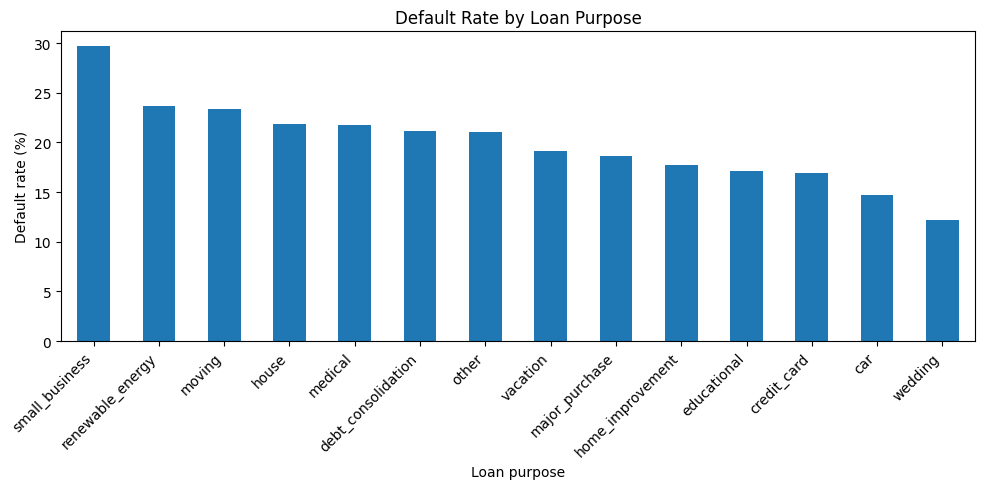

In [154]:
purpose_default_rate = df.groupby("purpose")["target"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
purpose_default_rate.plot(kind="bar")
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan purpose")
plt.ylabel("Default rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

A correlation heatmap of the numeric features checks for remaining redundancy and shows which features relate most strongly to the target.

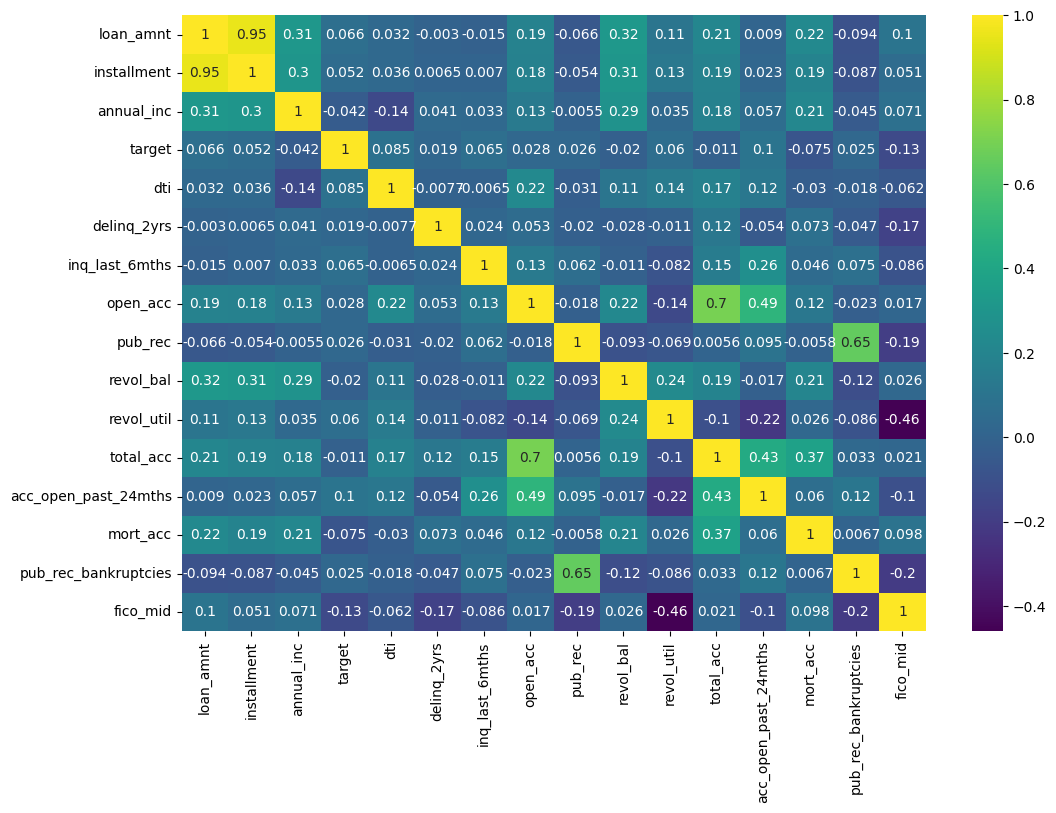

In [155]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="viridis")
plt.show()

The loan-amount and installment distributions are compared across the two classes, and each numeric feature's correlation with the target is ranked.


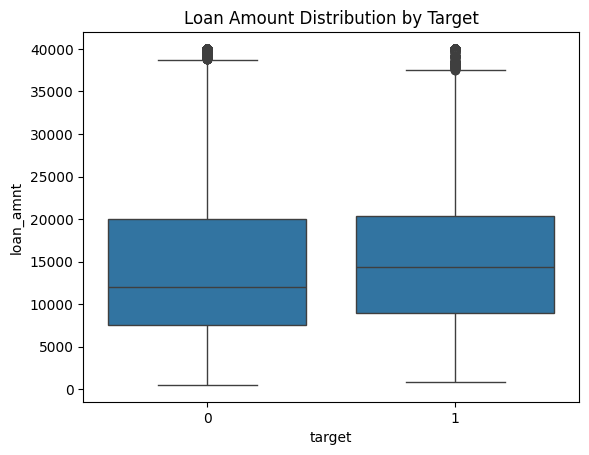

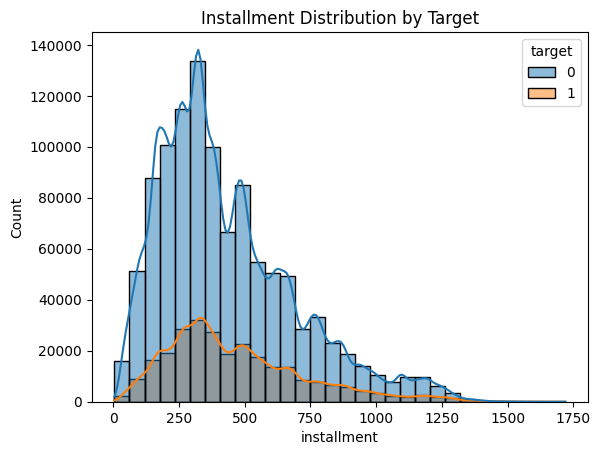

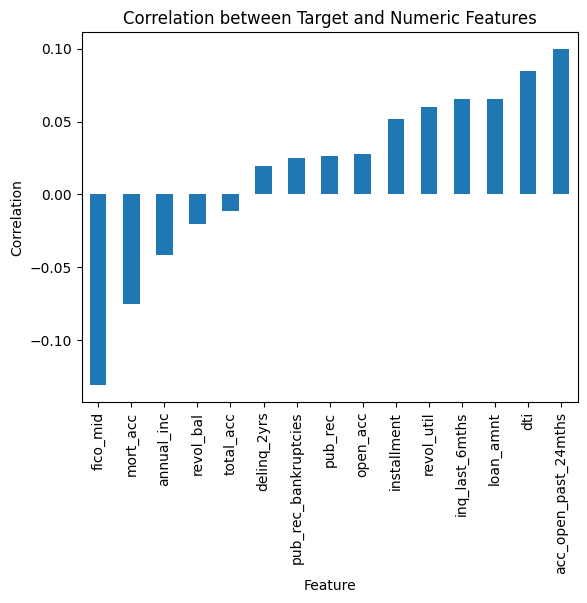

In [156]:
boxplot = sns.boxplot(x="target", y="loan_amnt", data=df)
boxplot.set_title("Loan Amount Distribution by Target")
plt.show()

installment_plot = sns.histplot(data=df, x="installment", hue="target", kde=True, bins=30)
installment_plot.set_title("Installment Distribution by Target")
plt.show()

df.corr(numeric_only=True)["target"].drop("target").sort_values().plot(
    kind="bar",
    title="Correlation between Target and Numeric Features",
    ylabel="Correlation",
    xlabel="Feature",
)
plt.show()

The skewness of every numeric feature is summarised to identify heavily right-skewed monetary variables — candidates for the log transformation applied in Section 3.2.


In [157]:
# Inspect skewness of numeric variables
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features = [col for col in numeric_features if col != "target"]

# Exclude target-like or non-feature columns if still present
exclude_from_skew_check = ["loan_status"]
numeric_features = [col for col in numeric_features if col not in exclude_from_skew_check]

skew_summary = pd.DataFrame({
    "feature": numeric_features,
    "mean": [df[col].mean() for col in numeric_features],
    "median": [df[col].median() for col in numeric_features],
    "skewness": [df[col].skew() for col in numeric_features],
    "min": [df[col].min() for col in numeric_features],
    "max": [df[col].max() for col in numeric_features],
    "unique_values": [df[col].nunique(dropna=True) for col in numeric_features],
})

skew_summary = skew_summary.sort_values("skewness", ascending=False).reset_index(drop=True)

display(skew_summary)

,feature,mean,median,skewness,min,max,unique_values
0,annual_inc,76247.636414,65000.00,46.317938,0.00,10999200.00,64362
1,dti,18.282667,17.61,27.110581,-1.00,999.00,7067
2,revol_bal,16248.114860,11134.00,13.749924,0.00,2904836.00,83810
3,pub_rec,0.215276,0.00,11.556255,0.00,86.00,37
4,delinq_2yrs,0.317794,0.00,5.603631,0.00,39.00,31
5,pub_rec_bankruptcies,0.134444,0.00,3.441174,0.00,12.00,12
6,inq_last_6mths,0.655081,0.00,1.696042,0.00,8.00,9
7,mort_acc,1.670783,1.00,1.637013,0.00,51.00,39
8,acc_open_past_24mths,4.692870,4.00,1.370004,0.00,64.00,55
9,open_acc,11.593520,11.00,1.296170,0.00,90.00,84


Finally, interquartile-range bounds are computed for the main continuous features to quantify how prevalent extreme values are, and the standardised distributions are shown as boxplots. This motivates the robust scaling used in the modeling pipeline (Section 5.2).


,outlier_count,outlier_percentage
revol_bal,79691,5.923616
annual_inc,65870,4.896269
fico_mid,46497,3.456229
installment,42042,3.125079
loan_amnt,7157,0.531996
dti,5473,0.406821
revol_util,72,0.005352


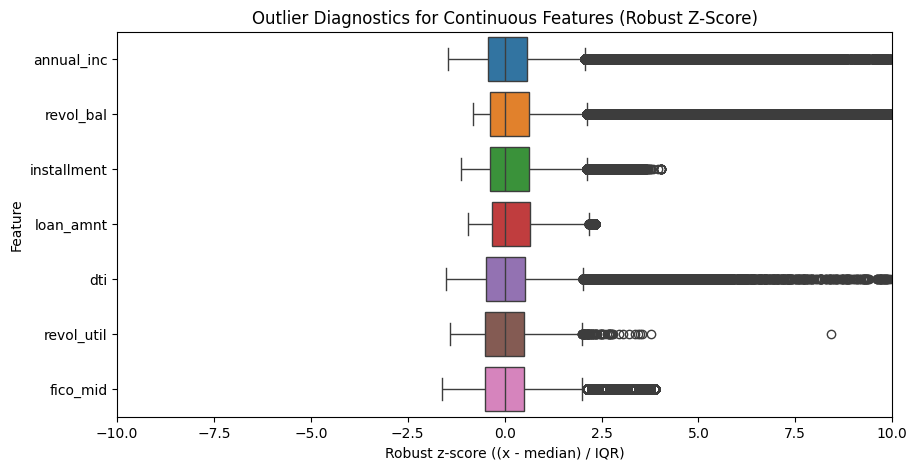

In [158]:
continuous_cols = [
    "annual_inc",
    "revol_bal",
    "installment",
    "loan_amnt",
    "dti",
    "revol_util",
    "fico_mid"
]

Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)

outlier_summary = pd.DataFrame({
    "outlier_count": outlier_mask.sum(),
    "outlier_percentage": outlier_mask.mean() * 100
}).sort_values("outlier_percentage", ascending=False)

display(outlier_summary)

# Robust z-score (median / IQR) instead of mean or std
df_boxplot = df[continuous_cols].copy()
median = df_boxplot.median()
iqr = df_boxplot.quantile(0.75) - df_boxplot.quantile(0.25)
df_boxplot = (df_boxplot - median) / iqr

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_boxplot, orient="h")
plt.title("Outlier Diagnostics for Continuous Features (Robust Z-Score)")
plt.xlabel("Robust z-score ((x - median) / IQR)")
plt.ylabel("Feature")
plt.xlim(-10, 10)
plt.show()

## 3. Data Preparation

This chapter prepares the pruned dataset for modelling. First, categorical variables are encoded so that all features can be used in numeric models. Then, missing values and skewed variables are handled to make the input matrix more stable. Finally, five controlled imbalance levels are created, ranging from 1% to 20% minority observations. These constructed datasets form the basis for the experimental comparison in the rest of the study.


### 3.1 Categorical Encoding

Categorical variables are encoded based on their meaning and structure. Variables with a clear order are encoded ordinally, while variables where a numeric value is embedded in text are converted into numeric form. For date based variables, a duration is derived where this provides more useful information than the original date. The remaining categorical variables do not have a natural order and are therefore one hot encoded in Section 3.2, after row level cleaning. This results in a fully numeric feature matrix that can be used in the resampling and modelling pipeline.



`emp_length` has a natural order (years of employment), so it is ordinally encoded 0–10.

In [159]:
df["emp_length"] = df["emp_length"].map({
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9, "10+ years": 10,
})

print("emp_length missing after ordinal encoding:", int(df["emp_length"].isna().sum()))

emp_length missing after ordinal encoding: 78511


`term` embeds the number of months as text (e.g. "36 months"), so missing values are filled with the modal term first, then the text is stripped down to an integer month count.

In [160]:
df["term"] = df["term"].fillna("36 months")
df["term"] = df["term"].str.strip().str.replace(" months", "").astype(int)

`earliest_cr_line` is stored as a month and year string, such as `"Aug-2003"`. This variable is first converted into a date format in a way that does not depend on the system locale. Afterwards, a numeric `credit_history_years` variable is calculated using a fixed reference date. The original date column is then removed, because the imputation and modelling steps require numeric input.


In [161]:
locale.setlocale(locale.LC_TIME, 'C')  # ensure month abbreviations parse as English regardless of system locale
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y")

# Derive a numeric feature: length of credit history in years, measured from the
# most recent origination date in the data (a fixed reference, so no per-row leakage).
reference_date = df["earliest_cr_line"].max()
df["credit_history_years"] = (
    (reference_date - df["earliest_cr_line"]).dt.days / 365.25
)

# The raw datetime column cannot be consumed by the numeric imputer/estimators
# downstream, so drop it once the numeric feature has been derived.
df = df.drop(columns=["earliest_cr_line"])

### 3.2 Transformations and Missing Values

`annual_inc` and `revol_bal` are strongly right skewed monetary variables. Both variables are therefore transformed using `log1p`, which reduces the influence of extreme values while still allowing zero values to be handled correctly. The transformed variables are stored in a single `LOG_FEATURES` set. This is needed later in Chapter 7, because the adversarial attacks must be able to move between the log transformed model space and the original dollar values for these same variables.


In [162]:
LOG_FEATURES = {"annual_inc", "revol_bal"}

for col in LOG_FEATURES:
    df[col] = np.log1p(df[col])

The remaining missing values are inspected to decide whether they should be imputed or removed. Imputation is not performed at this stage, but is postponed to the imputer step in the modelling pipeline in Section 5.2. This ensures that imputation is fitted separately within each cross-validation fold, preventing information from the full dataset from leaking into the training process. At this point, only rows with too many missing values are removed, since these observations contain too little usable information.


In [163]:
null_counts = df.isnull().sum()
print("Remaining missing values per column:")
print(null_counts[null_counts > 0])

rows_missing_loan_amnt = df[df["loan_amnt"].isnull()]
print(f"\nRows with loan_amnt missing: {len(rows_missing_loan_amnt)}")
print("Missing-value counts within those rows:")
print(rows_missing_loan_amnt.isnull().sum())

Remaining missing values per column:
emp_length              78511
dti                       374
inq_last_6mths              1
revol_util                857
acc_open_past_24mths    47281
mort_acc                47281
pub_rec_bankruptcies      697
dtype: int64

Rows with loan_amnt missing: 0
Missing-value counts within those rows:
loan_amnt               0
term                    0
installment             0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
target                  0
purpose                 0
addr_state              0
dti                     0
delinq_2yrs             0
inq_last_6mths          0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
acc_open_past_24mths    0
mort_acc                0
pub_rec_bankruptcies    0
fico_mid                0
credit_history_years    0
dtype: int64


The rows missing `loan_amnt` are missing nearly every other field as well, so they carry no usable signal and are dropped rather than imputed.

In [164]:
df = df.dropna(subset=["loan_amnt"])

print("Missing values remaining after the drop:")
print(df.isnull().sum().sum())

Missing values remaining after the drop:
175002


Finally, the remaining categorical columns are one-hot encoded, with the first level of each dropped to avoid collinearity in the design matrix.

In [165]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Columns one-hot encoded:", categorical_cols)

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Columns one-hot encoded: ['home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status']


### 3.3 Constructing the Five Imbalance Levels

The natural minority share in the dataset is around 20%, which is relatively mild compared to many financial datasets. Since the research question requires controlled class imbalance, five datasets are constructed with minority shares of 1%, 2%, 5%, 10%, and 20%. This is done by randomly subsampling the default class.

Subsampling can change the marginal distributions of the minority class. Therefore, each constructed dataset is checked with a Kolmogorov Smirnov test against the full source data. The cell below creates the five datasets and stores the resulting KS statistics for visualisation.


In [166]:
#Kolmogorov-Smirnov test per numeric column between the source data and a subsample
def calc_bias(source_df, sampled_df):
    results = {}
    for col in source_df.select_dtypes(include="number").columns:
        stat, p_value = ks_2samp(source_df[col], sampled_df[col])
        results[col] = (stat, p_value)
    return results

# Construct the five imbalance levels and check subsample bias via a Kolmogorov-Smirnov test against the source distribution
datasets = {}
ks_results = {}
minority_fractions = [0.01, 0.02, 0.05, 0.1, 0.2]

majority = df[df["target"] == 0]
minority = df[df["target"] == 1]
natural_fraction = len(minority) / (len(minority) + len(majority))
print(f"Natural minority fraction: {natural_fraction:.3f}")

for frac in minority_fractions:
    if frac <= natural_fraction:
        n_minority = int(round(frac / (1 - frac) * len(majority)))
        majority_part = majority
        minority_part = minority.sample(n=n_minority, random_state=RANDOM_STATE)
    else:
        n_majority = int(round((1 - frac) / frac * len(minority)))
        majority_part = majority.sample(n=n_majority, random_state=RANDOM_STATE)
        minority_part = minority

    subsample = (
        pd.concat([majority_part, minority_part])
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    X = subsample.drop(columns="target")
    y = subsample["target"]
    datasets[frac] = (X, y)

    bias = calc_bias(df, subsample)
    # Keep only the KS statistic (drop the p-value) and drop columns where the test is undefined.
    ks_results[frac] = {
        col: stat for col, (stat, _) in bias.items() if pd.notna(stat)
    }

    print(f"\nMinority fraction: {frac}")
    print(y.value_counts())
    print(y.value_counts(normalize=True))
    print("Bias statistics (Kolmogorov-Smirnov test):")
    print(bias)

Natural minority fraction: 0.200

Minority fraction: 0.01
target
0    1076751
1      10876
Name: count, dtype: int64
target
0    0.99
1    0.01
Name: proportion, dtype: float64
Bias statistics (Kolmogorov-Smirnov test):
{'loan_amnt': (np.float64(0.015728039077805678), np.float64(1.1692376504046194e-129)), 'term': (np.float64(0.03562055417328169), np.float64(0.0)), 'installment': (np.float64(0.013581308432251415), np.float64(8.697048288395085e-97)), 'emp_length': (np.float64(nan), np.float64(nan)), 'annual_inc': (np.float64(0.013683277355135304), np.float64(3.068570114587227e-98)), 'target': (np.float64(0.18962635672744466), np.float64(0.0)), 'dti': (np.float64(nan), np.float64(nan)), 'delinq_2yrs': (np.float64(0.003383159739621), np.float64(2.0941518146029804e-06)), 'inq_last_6mths': (np.float64(nan), np.float64(nan)), 'open_acc': (np.float64(0.0055687780552112764), np.float64(1.2579609846216283e-16)), 'pub_rec': (np.float64(0.005625562504159798), np.float64(5.855830423285003e-17)), 'r

The KS statistics across the five imbalance levels are visualised below. The first plot shows the KS trajectory for each feature, while the second plot presents the same information as an imbalance ratio by feature heatmap. This makes it easier to identify whether any feature distribution changes noticeably after subsampling, before the constructed datasets are used for resampling and modelling.


,loan_amnt,term,installment,annual_inc,target,delinq_2yrs,open_acc,pub_rec,revol_bal,total_acc,fico_mid,credit_history_years
minority_fraction,,,,,,,,,,,,
0.01,0.015728,0.035621,0.013581,0.013683,0.189626,0.003383,0.005569,0.005626,0.003486,0.003322,0.026312,0.010426
0.02,0.014932,0.033686,0.012900,0.012944,0.179626,0.003140,0.005325,0.005263,0.003301,0.003134,0.024918,0.009907
0.05,0.012472,0.028093,0.010745,0.010797,0.149626,0.002561,0.004444,0.004397,0.002740,0.002569,0.020804,0.008240
0.10,0.008322,0.018768,0.007172,0.007136,0.099626,0.001739,0.002941,0.002912,0.001806,0.001767,0.013985,0.005433
0.20,0.000049,0.000087,0.000032,0.000053,0.000374,0.000017,0.000036,0.000006,0.000035,0.000032,0.000034,0.000066


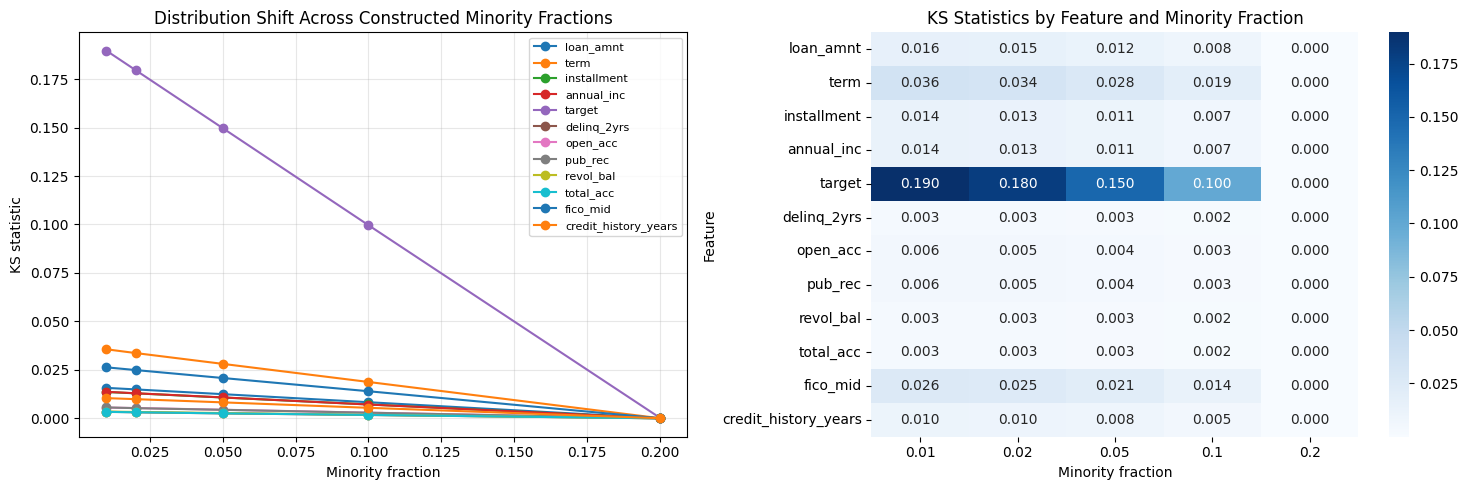

In [167]:
# Visualize KS statistics across imbalance levels
ks_df = pd.DataFrame(ks_results).T
ks_df.index.name = "minority_fraction"
display(ks_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for col in ks_df.columns:
    axes[0].plot(ks_df.index, ks_df[col], marker="o", label=col)
axes[0].set_title("Distribution Shift Across Constructed Minority Fractions")
axes[0].set_xlabel("Minority fraction")
axes[0].set_ylabel("KS statistic")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

sns.heatmap(ks_df.T, annot=True, fmt=".3f", cmap="Blues", ax=axes[1])
axes[1].set_title("KS Statistics by Feature and Minority Fraction")
axes[1].set_xlabel("Minority fraction")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

A set of sanity checks verifies that the base rate has not drifted and that all expected (non-one-hot) columns are still present before the experimental grid is built on top of these datasets.


In [168]:
expected_final_columns = {
    "loan_amnt", "term", "installment", "emp_length", "annual_inc", "dti", "delinq_2yrs",
     "credit_history_years", "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "mort_acc", "pub_rec_bankruptcies", "fico_mid", "target",
}

# Verify base rate
base_rate_check = df["target"].mean()
assert abs(base_rate_check - 0.20) < 0.001, f"Base rate drifted: {base_rate_check:.4f}"

# Verify the non-one-hot-encoded numeric/derived columns are still present (one-hot dummy columns
# are excluded from this check by construction, since their exact names depend on category labels
# seen at encoding time)
missing_expected = expected_final_columns - set(df.columns)
assert not missing_expected, f"Missing expected columns: {missing_expected}"

# Verify imbalance levels
assert set(datasets.keys()) == {0.01, 0.02, 0.05, 0.1, 0.2}, f"Unexpected dataset keys: {set(datasets.keys())}"

# Verify shared downstream variables exist
for name, value in [
    ("LOG_FEATURES", LOG_FEATURES),
    ("RANDOM_STATE", RANDOM_STATE),
    ("calc_bias", calc_bias),
]:
    assert value is not None, f"{name} is not defined"

print("All verification checks passed:")
print(f" - Base default rate: {base_rate_check:.2%} (expected ~20.0%)")
print(f" - Final feature set contains all expected columns")
print(f" - datasets keys: {sorted(datasets.keys())}")
print(f" - LOG_FEATURES: {LOG_FEATURES}")
print(f" - RANDOM_STATE: {RANDOM_STATE}")
print(f" - calc_bias is defined: {callable(calc_bias)}")

All verification checks passed:
 - Base default rate: 19.96% (expected ~20.0%)
 - Final feature set contains all expected columns
 - datasets keys: [0.01, 0.02, 0.05, 0.1, 0.2]
 - LOG_FEATURES: {'annual_inc', 'revol_bal'}
 - RANDOM_STATE: 42
 - calc_bias is defined: True


## 4. Resampling Strategies

Resampling is one of the main elements of this study and is therefore discussed in a separate chapter. This chapter explains why resampling is relevant when working with imbalanced credit default data and describes the five strategies used in the experimental setup: Baseline, Class Weight, Random Under Sampling, SMOTE ENN, and KMeans SMOTE. Each method is discussed in the same way by explaining what it does, how it works, its strengths and weaknesses, and what behaviour can be expected. The actual implementation of these methods is included later in the modelling chapter in Section 5.1. This chapter focuses only on the theoretical role of each resampling strategy.


### 4.1 The Role of Resampling

Resampling changes the training distribution so that the minority class receives a stronger learning signal. When the data is highly imbalanced, a model can achieve a low loss by mostly focusing on the majority class and largely ignoring defaults. Resampling addresses this by either changing the observations used during training, for example by adding or removing rows, or by changing how strongly each class contributes to the loss function.

The five strategies in this study cover the main approaches to class imbalance. These are no treatment as the control setting, cost-sensitive learning, under-sampling, a hybrid method that combines over-sampling with cleaning, and cluster-based over-sampling. Sections 4.2 to 4.6 explain each method separately. Section 4.7 then compares them side by side and clarifies where resampling is applied in the training pipeline.


### 4.2 Baseline (No Resampling)

**What it does.** The model is trained on the raw, imbalanced dataset without any modification.

**Mechanism.** None — class proportions mirror the original data distribution (1%–20% minority, depending on the imbalance level set for that experiment run).

**Strengths.** The baseline serves as the **experimental control**: without it, the effect of any resampling strategy cannot be quantified. It also represents the naive default choice a practitioner might make if they simply run a classifier without addressing imbalance, and it adds no computational cost or synthetic data.

**Weaknesses.** Under heavy imbalance, nothing counteracts the model's incentive to favour the majority class.



### 4.3 Class-Weight (Cost-Sensitive Learning)

**What it does.** Class-weight does **not change the data at all**. Instead, it modifies the **loss function** so that misclassifying a minority-class instance (a defaulter) incurs a higher penalty than misclassifying a majority-class instance.

**Mechanism.** In this implementation, `class_weight='balanced'` is passed to `LogisticRegression` and `RandomForestClassifier`, `scale_pos_weight` is passed to XGBoost, and the criterion weights of the neural network are adjusted based on the imbalance ratio (see `apply_class_weight` in Section 5.4).

**Strengths.**
- **No information loss**: every original training observation is used.
- **No synthetic points**: avoids introducing artificial data that might distort the feature manifold.
- **Fast**: no resampling step adds to training time.

**Weaknesses.** It does not help if the minority class is inherently hard to learn because it is embedded inside the majority region in feature space, and it is not directly applicable to all model types in the same way.

![Class-weight](./pictures/classweight.png)

### 4.4 Random Under-Sampling

**What it does.** Random Under-Sampling (RUS) randomly **removes majority-class instances** from the training set until the desired class ratio is reached (typically 1:1 or the target ratio).

**Mechanism.** Uniform random deletion of majority rows, hence no interpolation or clustering is needed.

**Strengths.**
- **Computationally trivial.**
- **Produces a compact, clean decision boundary**, where the reduced majority class leaves more "room" for the minority, producing simpler, harder-to-traverse boundaries for an adversary.
- In these experiments it is among the more robust strategies against adversarial perturbations, and it is the most hardened choice for the random forest (see Chapter 7).

**Weaknesses.**
- **Information loss**: discarded majority instances may contain useful signal.
- At extreme imbalance (1% minority), RUS discards the vast majority of the dataset, which can hurt generalisation.


![RUS](./pictures/RUS.png)


### 4.5 SMOTE-ENN (Hybrid)

**What it does.** SMOTE-ENN is a **two-stage hybrid** method that first over-samples the minority class using SMOTE, then cleans noisy instances from both classes using the Edited Nearest Neighbours (ENN) rule.

**Mechanism.**
- *Stage 1 — SMOTE (Synthetic Minority Over-sampling TEchnique).* For each minority instance $x_i$, find its $k$ nearest minority-class neighbours (default $k=5$), randomly select one neighbour $x_{nn}$, and generate a synthetic point along the line segment between them. Synthetic points therefore interpolate **within** the minority feature manifold rather than extrapolating.
- *Stage 2 — ENN (Edited Nearest Neighbours).* For each instance (from both classes) in the resampled set, check its $k$ nearest neighbours; if the majority of those neighbours belong to a **different class**, remove the instance. This strips misclassified, noisy, or borderline examples from both classes, producing a cleaner decision boundary with reduced class overlap.

**Strengths.**
- Reduces overlap between classes that vanilla SMOTE ignores.
- Keeps the minority class better separated from the majority.

**Weaknesses.**
- **Computationally expensive**: both SMOTE and ENN require nearest-neighbour searches.
- **Aggressive cleaning at high imbalance**: at 1–2% minority share, ENN can remove a large fraction of the newly generated synthetic minority points, potentially leaving the minority class even more underrepresented.

![SMOTE-ENN](./pictures/SMOTE.png)


### 4.6 KMeans-SMOTE

**What it does.** KMeans-SMOTE (Douzas et al., 2018) addresses a key weakness of vanilla SMOTE: it blindly synthesises in all minority regions, even near the majority-class boundary. KMeans-SMOTE adds a clustering step to restrict synthesis to "safe" minority clusters.

**Mechanism.**
1. **K-Means clustering**: run K-Means on the entire dataset (both classes combined); each cluster receives a label based on which class dominates it.
2. **Cluster filtering**: only clusters with sufficiently high minority-class density (above `cluster_balance_threshold`) are selected for synthesis, keeping synthetic points away from majority-dominated regions.
3. **SMOTE within clusters**: apply standard SMOTE interpolation *within* each selected minority-dense cluster.

The intuition is that synthesis is only safe within regions that are already "minority territory"; generating points near the majority boundary risks creating noisy synthetic instances that confuse the classifier.

**Strengths.**
- Reduces class overlap compared to vanilla SMOTE by restricting synthesis to dense minority clusters.
- Usually outperforms SMOTE and several variants on benchmark datasets.

**Weaknesses.**
- **Sparse minority clusters at high imbalance**: at 1% minority share, the minority class may be too sparse to form reliable clusters; K-Means may fail to identify any valid minority cluster or produce very few synthetic points, effectively falling back to vanilla-SMOTE behaviour in borderline regions.
- **Computational cost**: K-Means over the full dataset adds significant overhead at large $N$.

![KmeansSMOTE](./pictures/KMEANSMOTE.png)


### 4.7 Summary & Where Resampling Sits in the Pipeline

The recap table below places the five strategies side by side; it supplements, not replaces, the per-method descriptions above.

| Strategy | Family | Data Changed? | Key Mechanism |
|---|---|---|---|
| **Baseline** | None | ✗ | Train on raw imbalanced data |
| **Class-Weight** | Cost-sensitive | ✗ | Penalise minority misclassifications in loss |
| **Random Under-Sampling (RUS)** | Under-sampling | ✓ (remove) | Randomly drop majority rows |
| **SMOTE-ENN** | Hybrid over+under | ✓ (add + remove) | Synthesise minority, then clean noisy points |
| **KMeans-SMOTE** | Over-sampling | ✓ (add) | Cluster-aware synthetic minority generation |


Placement in the pipeline matters as much as the choice of method:

> **Resampling is applied to the training partition only, inside each CV fold, and never to the validation or test set. It is therefore added as a pipeline step passed into the cross-validation function.**

This prevents data leakage. In this pipeline:

```
Raw LendingClub → Feature Engineering → Set Imbalance Ratio
     → Stratified Split + 5-fold CV
         └── [RESAMPLE on train fold only]
             → Model Fit → Evaluate on val/test fold (no resampling)
```

The Kolmogorov–Smirnov bias check of Section 3.3 confirms the constructed distributions are reasonable before evaluation proceeds. The executable configuration of these samplers, including the KMeans-SMOTE cluster-count selection, follows in Section 5.1.


## 5. Modelling

This chapter converts the prepared datasets from Chapter 3 and the resampling strategies from Chapter 4 into the experimental modelling setup. It defines the sampler configurations, the cross-validation pipeline, the scoring function, the hyperparameter search, and the four classifiers used in the study. Since training the complete grid of 4 models, 5 resampling strategies, and 5 imbalance levels is computationally expensive, the training cells below were executed on the HPC cluster. The resulting output files are loaded again from `outputs/` in Chapter 6.


### 5.1 KMeans SMOTE Setup and Sampler Definitions

KMeans SMOTE, explained in Section 4.6, requires the number of clusters to be specified. To choose a suitable value, the elbow method is applied. K Means is fitted for several cluster counts on the 10% minority dataset after mean imputation. For each number of clusters, the distortion and inertia are recorded to assess where adding extra clusters gives only limited additional improvement.


In [169]:
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}

X = datasets[0.1][0]  # Using the dataset with 10% minority fraction for clustering
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

K = range(10, 100, 10)

for k in K:
    print(f"Calculating distortions and inertias for k={k}...")

    kmeansModel = KMeans(n_clusters=k, random_state=RANDOM_STATE).fit(X_imputed)  # Using the dataset with 10% minority fraction for clustering
    distortions.append(sum(np.min(cdist(X_imputed, kmeansModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_imputed.shape[0])

    inertias.append(kmeansModel.inertia_)

    print(f"Distortion for k={k}: {distortions[-1]}")
    print(f"Inertia for k={k}: {inertias[-1]}")

    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

Calculating distortions and inertias for k=10...
Distortion for k=10: 858192.8825335873
Inertia for k=10: 1026733382734.3711
Calculating distortions and inertias for k=20...
Distortion for k=20: 190107.8558622036
Inertia for k=20: 227443137674.98425
Calculating distortions and inertias for k=30...
Distortion for k=30: 60144.58682617889
Inertia for k=30: 71956382232.97617
Calculating distortions and inertias for k=40...
Distortion for k=40: 39998.34224978154
Inertia for k=40: 47853616684.21785
Calculating distortions and inertias for k=50...
Distortion for k=50: 24217.211109649925
Inertia for k=50: 28973229199.475185
Calculating distortions and inertias for k=60...
Distortion for k=60: 18661.635402790154
Inertia for k=60: 22326593979.545666
Calculating distortions and inertias for k=70...
Distortion for k=70: 14491.408514062177
Inertia for k=70: 17337376232.138634
Calculating distortions and inertias for k=80...
Distortion for k=80: 11662.783949157454
Inertia for k=80: 13953238088.93301

Distortion values:
10 : 858192.8825335873
20 : 190107.8558622036
30 : 60144.58682617889
40 : 39998.34224978154
50 : 24217.211109649925
60 : 18661.635402790154
70 : 14491.408514062177
80 : 11662.783949157454
90 : 9828.60956118851


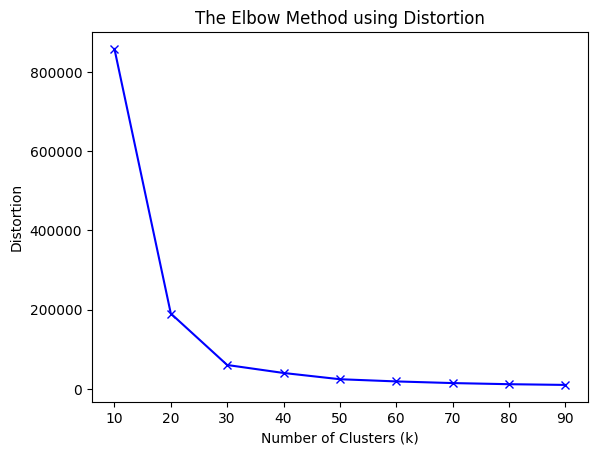

In [170]:
# The distortion values are printed and plotted against the number of clusters.
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

Inertia values:
10 : 1026733382734.3711
20 : 227443137674.98425
30 : 71956382232.97617
40 : 47853616684.21785
50 : 28973229199.475185
60 : 22326593979.545666
70 : 17337376232.138634
80 : 13953238088.93301
90 : 11758850192.909733


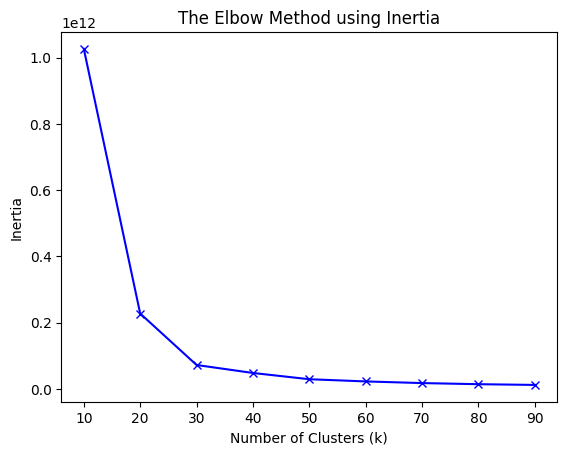

In [171]:
# The inertia values are printed and plotted the same way, as a second view on the elbow.
print("Inertia values:")
for key, val in mapping2.items():
    print(f'{key} : {val}')

plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.show()

Looking at the figures we see the elbow at 30 so we assign our variable to that value

In [172]:
NUM_CLUSTERS = 30  # Chosen based on the elbow method results

All five resampling strategies are defined in one dictionary, using the strategy names as keys. `Baseline` and `ClassWeight` are mapped to `None`, because they do not directly change the training data. For `ClassWeight`, the imbalance is handled later inside the estimator itself through the `apply_class_weight` function in Section 5.4.


In [173]:
samplers = {
    "Baseline": None,   
    "RandomUnderSampler": RandomUnderSampler(sampling_strategy="majority", random_state=RANDOM_STATE),
    "SMOTEENN":           SMOTEENN(sampling_strategy="minority", random_state=RANDOM_STATE, n_jobs=-1),
    "KMeansSMOTE": KMeansSMOTE(
        sampling_strategy="minority",
        random_state=RANDOM_STATE,
        cluster_balance_threshold=0.01,
        kmeans_estimator=MiniBatchKMeans(n_clusters=NUM_CLUSTERS, random_state=RANDOM_STATE, n_init=3),
        n_jobs=-1,
    ),
    "ClassWeight":        None,
}

5.2 Helper Functions
This section defines every helper function used by the training pipeline, grouped into three cells: pipeline construction and thresholding, SHAP explainability hooks, and the scoring / cross-validation / hyperparameter-search functions that drive the actual training loops in 5.4. Nothing here executes training yet — these are definitions only, called from Section 5.4 onward

### 5.2 Cross-Validation 

All experiments use stratified 5-fold cross-validation so that each fold preserves the (engineered) class ratio; the splitter is defined once and reused everywhere.


In [174]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 5.3. Pipeline Design

This section defines every helper function used by the training pipeline, grouped into three cells: pipeline construction and thresholding, SHAP explainability hooks, and the scoring / cross-validation / hyperparameter-search functions that drive the training loops in Section 5.4 (Models). Nothing here executes training yet, these are definitions only.


In [175]:
results = []

# Finds the classification threshold that maximises F1 on a set of predicted probabilities
def best_f1_threshold(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    return thresholds[np.argmax(f1[:-1])]

# Helper for NN models that expect float32 input
def to_float32(X):
    return np.asarray(X, dtype=np.float32)

# Build a pipeline with imputation, scaling, optional resampling, and the estimator
def build_pipeline(estimator, sampler):
    steps = [
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", RobustScaler()),
    ]
    if sampler is not None:
        steps.append(("sampler", sampler))
    if estimator.__class__.__name__ == "NeuralNetClassifier":
        steps.append(("to_float32", FunctionTransformer(to_float32)))
    steps.append(("clf", estimator))
    return ImbPipeline(steps)

In [176]:
# Compute SHAP values for a given model and sampler combination across all CV folds
shap_records = [] 

N_SHAP_MAX   = 200   # test samples for TreeExplainer / LinearExplainer
N_SHAP_NN    = 20    # test samples for NeuralNet (KernelExplainer is slow)
N_SHAP_NN_BG = 50    # background samples for KernelExplainer

# Applies the pipeline's transform steps while skipping resamplers, which don't act at inference time
def preprocess_for_shap(pipe, X):
    # Remove resampler steps from the pipeline, as they are not used at inference time and may not support transform().
    X_t = X
    for _, step in pipe.steps[:-1]:
        if hasattr(step, "fit_resample"): 
            continue
        X_t = step.transform(X_t)
    return np.asarray(X_t)


# Normalises SHAP output to shape (n_samples, n_features) for the positive class
def get_sv_class1(sv):
    # Normalise SHAP output to shape (n_samples, n_features) for the positive class.
    if isinstance(sv, list) and len(sv) == 2:
        return sv[1]
    if hasattr(sv, "values"):               
        v = sv.values
        return v[:, :, 1] if v.ndim == 3 else v
    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        return sv[:, :, 1]
    return sv


# Computes SHAP values for one CV fold's fitted pipeline and appends them to shap_records
def compute_shap_for_fold(pipe, train_idx, test_idx, X, model_name, sampler_name, imbalance_ratio):
    rng = np.random.default_rng(RANDOM_STATE)
    clf  = pipe.named_steps["clf"]
    feat = list(X.columns)

    try:
        if model_name in ("XGBClassifier", "RandomForestClassifier"):
            X_te = preprocess_for_shap(pipe, X.iloc[test_idx])
            idx  = rng.choice(len(X_te), min(N_SHAP_MAX, len(X_te)), replace=False)
            sv   = get_sv_class1(shap.TreeExplainer(clf).shap_values(X_te[idx]))

        elif model_name == "LogisticRegression":
            X_tr = preprocess_for_shap(pipe, X.iloc[train_idx])
            X_te = preprocess_for_shap(pipe, X.iloc[test_idx])
            idx  = rng.choice(len(X_te), min(N_SHAP_MAX, len(X_te)), replace=False)
            sv   = get_sv_class1(shap.LinearExplainer(clf, X_tr).shap_values(X_te[idx]))

        elif model_name == "NeuralNetClassifier":
            X_te_raw = X.iloc[test_idx].astype(np.float32)
            X_tr_raw = X.iloc[train_idx].astype(np.float32)
            ei = rng.choice(len(X_te_raw), min(N_SHAP_NN,    len(X_te_raw)),  replace=False)
            bi = rng.choice(len(X_tr_raw), min(N_SHAP_NN_BG, len(X_tr_raw)), replace=False)

            def nn_predict(X_raw):
                df = pd.DataFrame(X_raw, columns=feat).astype(np.float32)
                return pipe.predict_proba(df)[:, 1]

            sv = shap.KernelExplainer(nn_predict, X_tr_raw.iloc[bi]).shap_values(
                X_te_raw.iloc[ei], nsamples=100, l1_reg="num_features(10)"
            )
        else:
            return

        shap_records.append({
            "Model":           model_name,
            "Sampler":         sampler_name,
            "Imbalance ratio": imbalance_ratio,
            "importances":     pd.Series(np.abs(sv).mean(axis=0), index=feat),
        })

    except Exception as e:
        print(f"  SHAP skipped for {model_name}+{sampler_name} (IR={imbalance_ratio}): {e}")

### 5.4 Scoring, Training Loops & Hyperparameter Search

`score_model` takes the fold-level outputs of the stratified k-fold cross-validation run performed in `model_kfold` and turns them into a single row of comparable metrics for one (classifier, resampling method, imbalance ratio) combination, plus a confusion-matrix plot and a SHAP explanation. ROC-AUC and PR-AUC come straight from the CV scorers and are **threshold-free**: they summarise how well the model ranks positives above negatives across all possible thresholds. The remaining metrics are evaluated at each fold's F1-optimal threshold.



The metrics reported per configuration:

- **ROC-AUC (mean)** — threshold-independent; the probability that a randomly chosen positive case is scored above a randomly chosen negative case, averaged across folds.
- **PR-AUC (mean)** (`average_precision`) — also threshold-independent, but the area under the precision–recall curve. More informative than ROC-AUC under class imbalance, since it does not dilute false positives against a large negative class.
- **F1 (mean)** — macro-averaged F1 computed per fold at that fold's optimal threshold, then averaged across folds. Macro-averaging prevents the majority (non-default) class from dominating the score.
- **Precision (mean) / Recall (mean)** — macro-averaged, computed once on the pooled out-of-fold predictions. Reported separately from F1 because two models can share an F1 score while trading off precision and recall very differently — and false negatives (missed defaults) and false positives (rejected good borrowers) carry different real-world costs.
- **G-Mean (mean)** — the geometric mean of sensitivity and specificity, $G=\sqrt{TPR \times TNR}$, computed on the pooled out-of-fold predictions. Introduced specifically for imbalanced learning; it penalises a classifier that scores well on the majority class while failing the minority class.
- **Threshold (mean)** — the average of the per-fold F1-optimal thresholds, showing how far the operating point has moved from the naive 0.5 default.
- **Confusion matrix / TP, FP, TN, FN** — computed on the pooled out-of-fold predictions and displayed normalised by true class, so each row shows that class's recall directly; raw counts are stored in the results table.
- **Train F1 (mean) / F1 gap (train − test)** — an overfitting diagnostic, particularly relevant when comparing resampling methods, since synthetic oversampling can make a model fit its (synthetic) training distribution much better than it generalises.
- **Fit time / Score time** — per-fold wall-clock cost, useful for comparing practicality across the full 4×5×5 factorial design.


The cell below defines the full training machinery in one place: `score_model` (scoring and confusion-matrix plot), `model_kfold` (runs the 5-fold CV for one configuration), `apply_class_weight` (sets the correct class-weight parameter per model type), `loop_samplers` and `loop_imbalance_ratios` (the nested experiment loops), and `find_best_hyperparameters` (the grid search wrapped around the same imputer–scaler–classifier pipeline).


In [177]:
# Scores the model on the test set for each CV fold, computes metrics, and appends results to the global results list
def score_model(imbalance_ratio, cv_out, estimator, sampler_name, X, y, normalize='true'):
    y_arr = np.asarray(y)
    y_pred = np.empty_like(y_arr)
    fold_thresholds, train_f1s, test_f1s = [], [], []
    for est, train_idx, test_idx in zip(
        cv_out["estimator"], cv_out["indices"]["train"], cv_out["indices"]["test"]
    ):
        proba_train = est.predict_proba(X.iloc[train_idx])[:, 1]
        thr = best_f1_threshold(y_arr[train_idx], proba_train)
        proba_test = est.predict_proba(X.iloc[test_idx])[:, 1]
        y_pred[test_idx] = (proba_test >= thr).astype(y_arr.dtype)
        fold_thresholds.append(float(thr))
        train_f1s.append(f1_score(y_arr[train_idx], (proba_train >= thr).astype(y_arr.dtype), average="macro"))
        test_f1s.append(f1_score(y_arr[test_idx], y_pred[test_idx], average="macro"))

    cm = confusion_matrix(y_arr, y_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_arr))
    disp.plot(cmap="Blues", values_format=".2f" if normalize else "d")
    plt.title(f"{estimator.__class__.__name__} + {sampler_name} + imbalance ratio {imbalance_ratio} ({skf.get_n_splits()}-fold OOF)")
    plt.show()

    train_f1 = float(np.mean(train_f1s))
    test_f1 = float(np.mean(test_f1s))

    results.append({
        "Model": estimator.__class__.__name__,
        "Sampler": sampler_name,
        "Imbalance ratio": imbalance_ratio,
        "fit time (s)": round(cv_out["fit_time"].mean(), 2),
        "Score time (s)": round(cv_out["score_time"].mean(), 2),
        "Threshold (mean)": round(float(np.mean(fold_thresholds)), 4),
        "F1 (mean)":        test_f1,
        "ROC-AUC (mean)":   cv_out["test_roc_auc"].mean(),
        "PR-AUC (mean)":    cv_out["test_average_precision"].mean(),
        "Recall (mean)":    recall_score(y_arr, y_pred, average="macro"),
        "Precision (mean)": precision_score(y_arr, y_pred, average="macro"),
        "G-Mean (mean)":    geometric_mean_score(y_arr, y_pred),
        "Train F1 (mean)":  train_f1,
        "F1 gap (train-test)": round(train_f1 - test_f1, 3),
        "TP": cm[1, 1] if normalize else int(cm[1, 1]),
        "FP": cm[0, 1] if normalize else int(cm[0, 1]),
        "TN": cm[0, 0] if normalize else int(cm[0, 0]),
        "FN": cm[1, 0] if normalize else int(cm[1, 0])
    })
    
    compute_shap_for_fold(
        cv_out["estimator"][-1],
        cv_out["indices"]["train"][-1],
        cv_out["indices"]["test"][-1],
        X,
        estimator.__class__.__name__,
        sampler_name,
        imbalance_ratio,
    )

In [178]:
# Runs cross-validation for a given sampler and estimator, scores the model, and computes SHAP values
def model_kfold(sampler_name, estimator, X, y, imbalance_ratio=None):
    print(f"Training {estimator.__class__.__name__} + {sampler_name} with imbalance ratio {imbalance_ratio}...")

    print("Performing cross-validation...")
    time_start = process_time()

    sampler = samplers[sampler_name]

    pipe = build_pipeline(estimator, sampler)

    cv_out = cross_validate(
        pipe, X, y, cv=skf,
        scoring=("roc_auc", "average_precision"),
        return_train_score=True,
        return_estimator=True,
        return_indices=True,
        n_jobs=1,
    )

    print(f"Done in {round(process_time() - time_start, 2)} seconds.")

    score_model(imbalance_ratio, cv_out, estimator, sampler_name, X, y)

# Applies class weights to the estimator based on the sampler and the target distribution
def apply_class_weight(estimator, sampler_name, y):
    name = estimator.__class__.__name__
    y_arr = np.asarray(y)
    if sampler_name == "ClassWeight":
        if name in ("LogisticRegression", "RandomForestClassifier"):
            estimator.set_params(class_weight="balanced")
        elif name == "XGBClassifier":
            estimator.set_params(scale_pos_weight=(y_arr == 0).sum() / (y_arr == 1).sum())
        elif name == "NeuralNetClassifier":
            _, counts = np.unique(y_arr, return_counts=True)
            w = torch.tensor(counts.sum() / (2 * counts), dtype=torch.float32)
            estimator.set_params(criterion__weight=w)
    else:
        if name in ("LogisticRegression", "RandomForestClassifier"):
            estimator.set_params(class_weight=None)
        elif name == "XGBClassifier":
            estimator.set_params(scale_pos_weight=1.0)
        elif name == "NeuralNetClassifier":
            estimator.set_params(criterion__weight=None)
    return estimator

# Loops through all samplers for a given estimator and imbalance ratio, running cross-validation and scoring for each combination
def loop_samplers(estimator, X, y, imbalance_ratio):
    for sampler_name, sampler in samplers.items(): 
        model_kfold(sampler_name, apply_class_weight(estimator, sampler_name, y), X, y, imbalance_ratio=imbalance_ratio)

# Loops through all imbalance ratios for a given estimator, running cross-validation and scoring for each combination of sampler and imbalance ratio  
def loop_imbalance_ratios(estimator):
    for frac, dataset in datasets.items():
        print(f"=== Minority fraction: {frac} ===")
        X, y = dataset
        if estimator.__class__.__name__ == "NeuralNetClassifier":
            X = X.astype(np.float32)
            y = y.to_numpy().astype(np.int64)
            
        loop_samplers(estimator, X, y, imbalance_ratio=frac)         

# Performs hyperparameter tuning for a given estimator using GridSearchCV, and updates the global config dictionary with the best parameters found
def find_best_hyperparameters(estimator, X, y, param_distributions):
    param_distributions["clf__random_state"] = [RANDOM_STATE]
    pipe = ImbPipeline([
        #("imputer", KNNImputer(n_neighbors=5, weights="distance")),
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", RobustScaler()),
        ("clf", estimator)
    ])

    search = GridSearchCV(
        pipe,
        param_distributions,
        scoring="average_precision",
        refit=True,
        n_jobs=-1
    )
    search.fit(X, y)

    print("Best hyperparameters:")
    print(search.best_params_)
    print(f"Score with best hyperparameters: {search.best_score_:.4f}")
    config[estimator.__class__.__name__] = {k.removeprefix("clf__"): v for k, v in search.best_params_.items()}        



Before training on the various imbalance ratios we will first use gridsearch to find the optimal params for the models

In [179]:

config = {}


During testing, the grid search returned the following optimal configuration, which is hard-coded here so the notebook does not need to repeat the search.


In [180]:
config = {
  "XGBClassifier": {
    "colsample_bytree": 0.8,
    "eval_metric": "logloss",
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 10,
    "n_estimators": 800,
    "random_state": 42,
    "reg_lambda": 5,
    "subsample": 0.8
  },
  "LogisticRegression": {
    "C": 0.1,
    "max_iter": 2000,
    "penalty": "l2",
    "random_state": 42,
    "solver": "saga"
  },
  "RandomForestClassifier": {
    "max_features": "sqrt",
    "min_samples_leaf": 5,
    "n_estimators": 500,
    "random_state": 42
  }
}

Computes the majority-to-minority ratio at the 20% level, used as the positive-class weight where an explicit value is required.



In [181]:
weight = (datasets[0.2][1] == 0).sum() / (datasets[0.2][1] == 1).sum()

### 5.5 Models

Four classifiers are trained: **Logistic Regression** as the interpretable baseline, **Random Forest** and **XGBoost** as bagged and boosted tree ensembles, and a **Neural Network** as the fully black-box model. Together they span the interpretability–performance trade-off and the model families most commonly benchmarked in imbalanced credit-risk classification.


#### 5.4.1 XGBoost

The XGBoost parameter grid is defined and searched


In [ ]:

param_distributions_xgb = {
    "clf__n_estimators":     [400, 800],
    "clf__max_depth":        [4, 6],
    "clf__learning_rate":    [0.05, 0.1],
    "clf__min_child_weight": [1, 10],
    "clf__reg_lambda":       [1, 5],
    "clf__subsample":        [0.8],
    "clf__colsample_bytree": [0.8],
}


find_best_hyperparameters(XGBClassifier(), datasets[0.2][0], datasets[0.2][1], param_distributions_xgb)

In [ ]:
# Run the main loop for XGBClassifier with the tuned hyperparameters across all imbalance ratios and samplers
loop_imbalance_ratios(XGBClassifier(**config["XGBClassifier"]))

#### 5.4.2 Logistic Regression

The logistic-regression parameter grid (regularisation strength and penalty) is defined and searched.


In [ ]:
param_distributions_logistic= {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["saga"],
    "clf__max_iter": [2000],
}

find_best_hyperparameters(LogisticRegression(), datasets[0.2][0], datasets[0.2][1], param_distributions_logistic)

In [ ]:
# Run the main loop for LogisticRegression with the tuned hyperparameters across all imbalance ratios and samplers
loop_imbalance_ratios(LogisticRegression(**config["LogisticRegression"]))

#### 5.4.3 Random Forest

The random-forest parameter grid (depth, leaf size, feature subsampling) is defined and searched.


In [ ]:
param_distributions_random_forest = {
    "clf__n_estimators":     [500],
    "clf__max_depth":        [None, 16, 24],
    "clf__min_samples_leaf": [1, 5, 20],     
    "clf__max_features":     ["sqrt", 0.3],
} 

find_best_hyperparameters(RandomForestClassifier(), datasets[0.2][0], datasets[0.2][1], param_distributions_random_forest)

In [ ]:
# Run the main loop for RandomForestClassifier with the tuned hyperparameters across all imbalance ratios and samplers
loop_imbalance_ratios(RandomForestClassifier(**config["RandomForestClassifier"], n_jobs=-1))


## 5.6 Implement Neural Network

#### 5.4.4 Neural Network

`NeuralNetwork` is a small fully-connected feedforward network (multilayer perceptron) with two hidden layers:

| Layer | Operation | Output shape |
|---|---|---|
| Input | — | `(batch, input_dim)` |
| `layer_1` | Linear(`input_dim` → 64) | `(batch, 64)` |
| `activation_1` | ReLU | `(batch, 64)` |
| `dropout_1` | Dropout(p=0.2) | `(batch, 64)` |
| `layer_2` | Linear(64 → 64) | `(batch, 64)` |
| `activation_2` | ReLU | `(batch, 64)` |
| `dropout_2` | Dropout(p=0.2) | `(batch, 64)` |
| `layer_3` (output) | Linear(64 → 2) | `(batch, 2)` |

`input_dim` is set dynamically from the data rather than hardcoded, so the same class can be instantiated for datasets with different feature counts, relevant here since different resampling or preprocessing steps could in principle change the number of columns going in.


In [186]:
# Defines the network architecture as a PyTorch module
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.layer_1 = nn.Linear(input_dim, 64)
        self.activation_1 = nn.ReLU()
        self.dropout_1 = nn.Dropout(0.2)
        self.layer_2 = nn.Linear(64, 64)
        self.activation_2 = nn.ReLU()
        self.dropout_2 = nn.Dropout(0.2)
        self.layer_3 = nn.Linear(64, 2)

    def forward(self, X):

        X = self.layer_1(X)
        X = self.activation_1(X)
        X = self.dropout_1(X)
        X = self.layer_2(X)
        X = self.activation_2(X)
        X = self.dropout_2(X)
        X = self.layer_3(X)

        return X

n_features = next(iter(datasets.values()))[0].shape[1]

The neural network module is wrapped in a skorch `NeuralNetClassifier`. This allows the neural network to be used in the same pipeline as the scikit-learn models. The wrapper uses Adam as the optimiser, early stopping to prevent unnecessary training, and learning rate scheduling to adjust the learning process during training.


In [187]:
net_clf = NeuralNetClassifier(
    NeuralNetwork,
    module__input_dim=n_features,
    criterion=nn.CrossEntropyLoss,
    max_epochs=100,
    lr=0.001,
    device=device,
    optimizer=Adam,
    batch_size=512,
    iterator_train__shuffle=True,
    callbacks=[
    EarlyStopping(monitor='valid_loss', patience=10),
    LRScheduler(policy=ReduceLROnPlateau, monitor='valid_loss'),]
)

In [ ]:
# Runs the full sampler × imbalance-ratio loop for the neural network
loop_imbalance_ratios(net_clf)

=== Minority fraction: 0.01 ===
Training NeuralNetClassifier + Baseline with imbalance ratio 0.01...
Performing cross-validation...


KeyboardInterrupt: 

## 6. Evaluation

This chapter audits the trained grid on the first two of the study's three axes: clean predictive performance (Section 6.1, with SHAP-based feature-importance analysis in Section 6.2) and fairness via the Disparate Impact Ratio (Section 6.3). The third axis, adversarial robustness, is a headline contribution and gets its own chapter (Chapter 7).


When the training loops above have been run locally, the collected `results` are assembled into a DataFrame and written to disk.


In [183]:
model_results = pd.DataFrame(results)
model_results.to_csv("outputs/model_results.csv", index=False)
model_results

""


In the standard workflow, the result table produced on the HPC cluster is read back in, so the analysis below does not depend on rerunning the training.


In [184]:
model_results = pd.read_csv("outputs/model_results.csv")

EmptyDataError: No columns to parse from file

### 6.1 Predictive Performance

Before analysing adversarial robustness, the clean predictive performance of all model configurations is evaluated. This includes every combination of model, resampling strategy, and imbalance ratio in the 4 × 5 × 5 experimental design. Since the target variable is strongly imbalanced, one metric is not enough to describe performance properly. The results are therefore analysed from several perspectives: PR AUC trends per resampling method in Section 6.1.1, multi metric trends in Section 6.1.2, model and sampler heatmaps in Section 6.1.3, an overfitting diagnostic in Section 6.1.4, and the winning configurations with the overall sampler ranking in Section 6.1.5.

PR AUC and ROC AUC are threshold free ranking metrics. This means that they measure how well the model ranks default cases above non-default cases across all possible thresholds. F1, recall, precision, and G Mean are instead calculated at the F1 optimal threshold within each fold. Under heavy class imbalance, PR AUC and G Mean are especially important. A model can still obtain a reasonable F1 score or ROC AUC while effectively ignoring the default class. In that case, the G Mean becomes 0 because the model does not correctly identify any defaulters.


#### 6.1.1 Per-Sampler PR-AUC vs Imbalance Ratio

For each sampler, PR-AUC is plotted against the imbalance ratio per model, showing how the ranking quality of each model degrades as the minority share shrinks.


In [185]:
ir_col   = "Imbalance ratio"
y_col    = "PR-AUC (mean)"

unique_samplers = model_results["Sampler"].unique()
models   = model_results["Model"].unique()

n = len(unique_samplers)
ncols = 3
nrows = -(-n // ncols) 

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, sampler in zip(axes, unique_samplers):
    sub = model_results[model_results["Sampler"] == sampler]
    for model in models:
        m = sub[sub["Model"] == model].sort_values(ir_col)
        if m.empty:
            continue
        ax.plot(m[ir_col], m[y_col], marker="o", label=model)

    ax.set_title(sampler)
    ax.set_xlabel("Imbalance Ratio")
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.3)

for ax in axes[n:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=len(models), bbox_to_anchor=(0.5, 1.02))

fig.tight_layout()
plt.show()


KeyError: 'Sampler'

#### 6.1.2 Multi Metric Trajectories

The PR AUC results alone do not show all relevant trade-offs. Therefore, six metrics are plotted against the imbalance ratio: PR AUC, ROC AUC, F1, G Mean, recall, and precision. This makes it possible to compare threshold free ranking performance, minority class detection, and the precision recall trade-off for each resampling method.


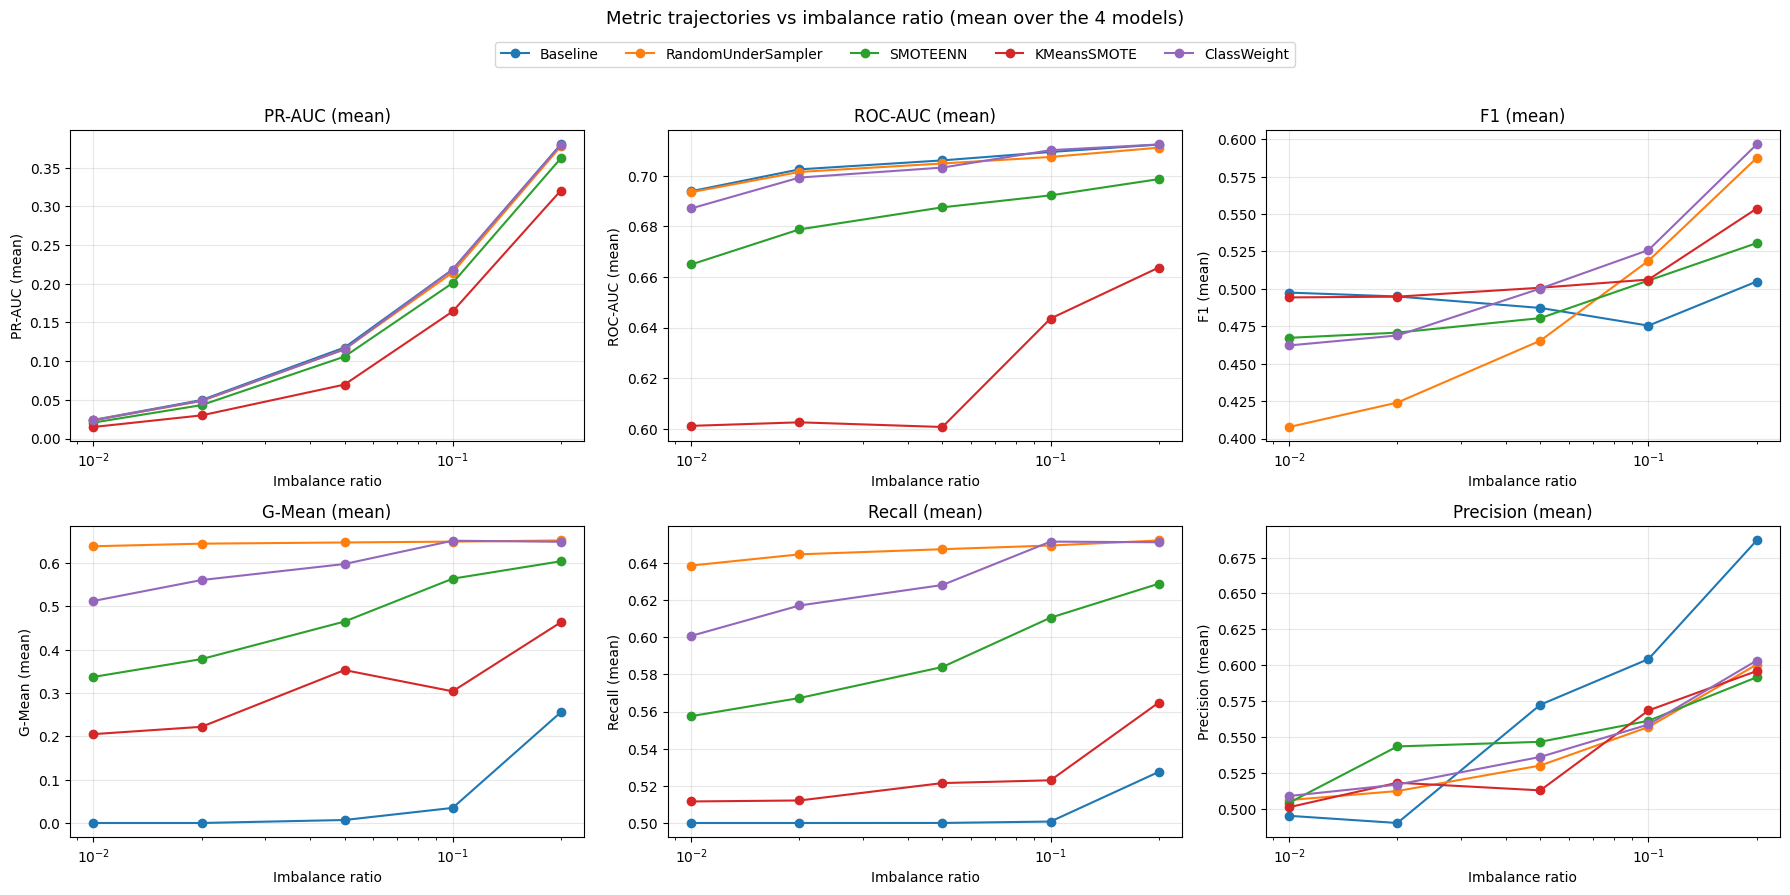

In [ ]:
ir_col  = "Imbalance ratio"

metrics = [
    "PR-AUC (mean)", "ROC-AUC (mean)", "F1 (mean)",
    "G-Mean (mean)", "Recall (mean)", "Precision (mean)",
]
metrics = [m for m in metrics if m in model_results.columns]

samplers = list(model_results["Sampler"].unique())

ncols = 3
nrows = -(-len(metrics) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, metric in zip(axes, metrics):
    for sampler in samplers:
        sub = (model_results[model_results["Sampler"] == sampler]
               .groupby(ir_col)[metric].mean().sort_index())
        ax.plot(sub.index, sub.values, marker="o", label=sampler)
    ax.set_title(metric)
    ax.set_xlabel("Imbalance ratio")
    ax.set_ylabel(metric)
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)

for ax in axes[len(metrics):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(samplers),
           bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Metric trajectories vs imbalance ratio (mean over the 4 models)",
             y=1.06, fontsize=13)
fig.tight_layout()
plt.show()

#### 6.1.3 Model × Sampler Performance Heatmaps

Averaging each metric across the five imbalance ratios gives a compact model × sampler grid, showing at a glance which combinations dominate.


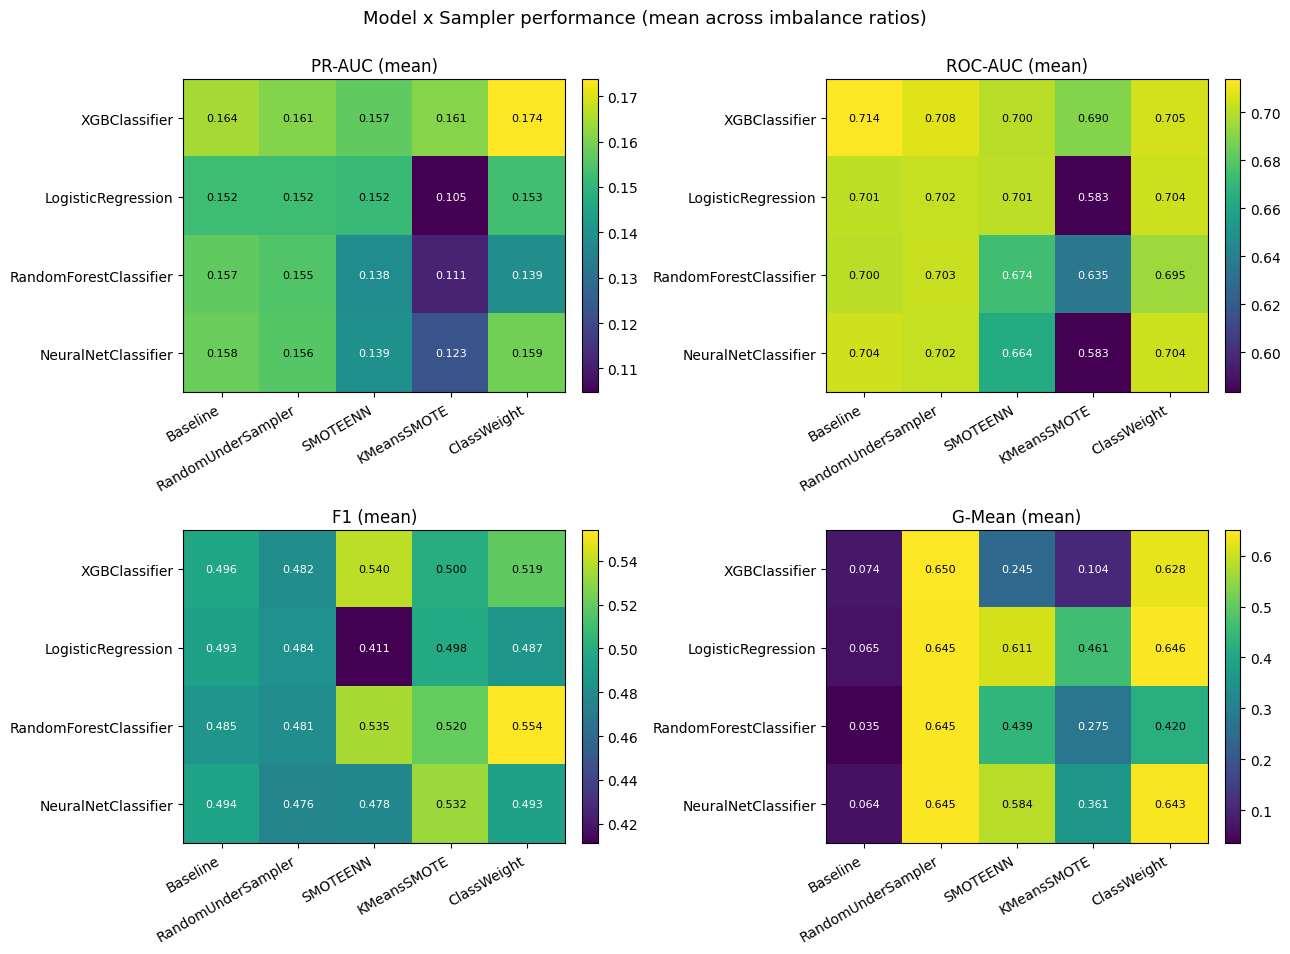

In [ ]:
heat_metrics = ["PR-AUC (mean)", "ROC-AUC (mean)", "F1 (mean)", "G-Mean (mean)"]
heat_metrics = [m for m in heat_metrics if m in model_results.columns]

models   = list(model_results["Model"].unique())
samplers = list(model_results["Sampler"].unique())

fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
axes = axes.flatten()

for ax, metric in zip(axes, heat_metrics):
    piv = (model_results.groupby(["Model", "Sampler"])[metric].mean()
           .unstack("Sampler").reindex(index=models, columns=samplers))
    im = ax.imshow(piv.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_title(metric)
    thr = np.nanmean(piv.values)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                        color="white" if v < thr else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[len(heat_metrics):]:
    ax.set_visible(False)

fig.suptitle("Model x Sampler performance (mean across imbalance ratios)",
             y=1.0, fontsize=13)
fig.tight_layout()
plt.show()

#### 6.1.4 Overfitting Diagnostic (Train–Test F1 Gap)

A large positive gap between training-fold and test-fold F1 signals a model that fits its (possibly synthetic) training distribution better than it generalises — especially relevant when comparing resamplers, since oversampling can inflate training performance. The bars show the mean gap for each sampler, broken down by model.


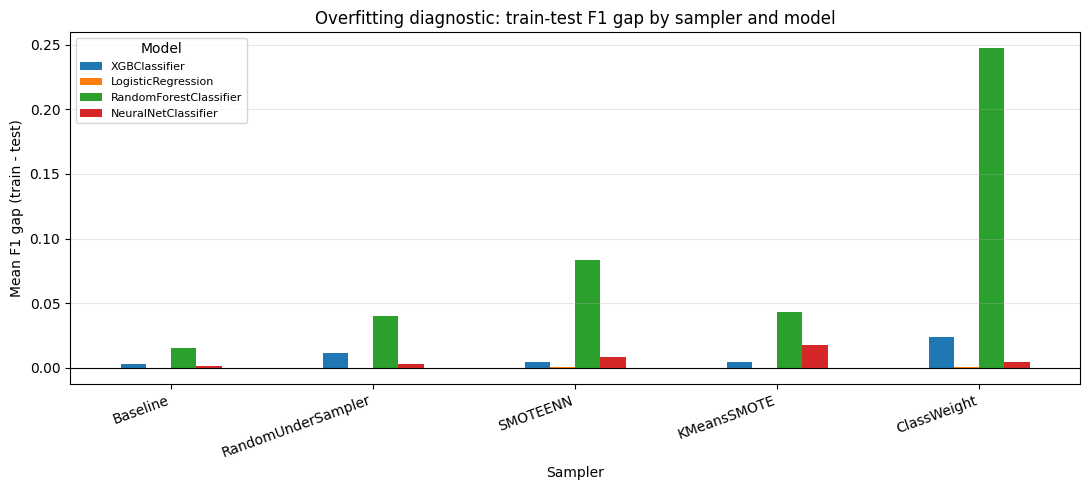

In [ ]:
gap_col  = "F1 gap (train-test)"
models   = list(model_results["Model"].unique())
samplers = list(model_results["Sampler"].unique())

piv = (model_results.groupby(["Sampler", "Model"])[gap_col].mean()
       .unstack("Model").reindex(index=samplers, columns=models))

fig, ax = plt.subplots(figsize=(11, 5))
piv.plot(kind="bar", ax=ax)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Mean F1 gap (train - test)")
ax.set_xlabel("Sampler")
ax.set_title("Overfitting diagnostic: train-test F1 gap by sampler and model")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="Model", fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
plt.show()

#### 6.1.5 Best Configurations and Sampler Ranking

For each combination of model and imbalance ratio, the resampling method with the highest PR AUC is reported. Afterwards, the resampling methods are ranked based on their average PR AUC rank across all combinations, where a rank of 1 indicates the best performance.


Best sampler per (model, imbalance ratio) by PR-AUC (mean):


,Model,Imbalance ratio,Sampler,PR-AUC (mean),ROC-AUC (mean),F1 (mean),G-Mean (mean)
0,LogisticRegression,0.01,ClassWeight,0.0247,0.7031,0.4169,0.6447
1,LogisticRegression,0.02,ClassWeight,0.0492,0.7059,0.4325,0.6476
2,LogisticRegression,0.05,ClassWeight,0.1138,0.7037,0.4719,0.6457
3,LogisticRegression,0.10,ClassWeight,0.2091,0.7033,0.5233,0.6465
4,LogisticRegression,0.20,Baseline,0.3676,0.7034,0.5088,0.2688
5,NeuralNetClassifier,0.01,Baseline,0.0236,0.6910,0.4975,0.0000
6,NeuralNetClassifier,0.02,ClassWeight,0.0500,0.6997,0.4405,0.6412
7,NeuralNetClassifier,0.05,ClassWeight,0.1186,0.7056,0.4720,0.6471
8,NeuralNetClassifier,0.10,ClassWeight,0.2186,0.7093,0.5208,0.6508
9,NeuralNetClassifier,0.20,ClassWeight,0.3840,0.7159,0.5891,0.6557


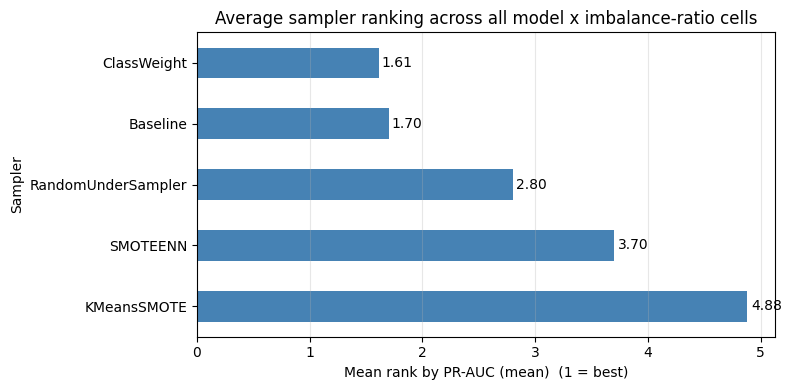

Times each sampler was best (out of 20 model x ratio cells):


,Times best
Sampler,
Baseline,10
ClassWeight,9
RandomUnderSampler,1


In [ ]:
ir_col      = "Imbalance ratio"
rank_metric = "PR-AUC (mean)"

# Best sampler for every (model, imbalance ratio) cell
show_cols = ["Model", ir_col, "Sampler", rank_metric,
             "ROC-AUC (mean)", "F1 (mean)", "G-Mean (mean)"]
show_cols = [c for c in show_cols if c in model_results.columns]
best_idx  = model_results.groupby(["Model", ir_col])[rank_metric].idxmax()
best = (model_results.loc[best_idx, show_cols]
        .sort_values(["Model", ir_col]).reset_index(drop=True))

print(f"Best sampler per (model, imbalance ratio) by {rank_metric}:")
display(best.round(4))

# Mean rank of each sampler within every (model, imbalance-ratio) group (1 = best)
mr = model_results.copy()
mr["_rank"] = (mr.groupby(["Model", ir_col])[rank_metric]
               .rank(ascending=False, method="average"))
sampler_rank = mr.groupby("Sampler")["_rank"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
sampler_rank.iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel(f"Mean rank by {rank_metric}  (1 = best)")
ax.set_title("Average sampler ranking across all model x imbalance-ratio cells")
for i, v in enumerate(sampler_rank.iloc[::-1].values):
    ax.text(v + 0.03, i, f"{v:.2f}", va="center")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

# How often each sampler was the top performer
win = best["Sampler"].value_counts().to_frame("Times best")
print(f"Times each sampler was best (out of {len(best)} model x ratio cells):")
display(win)

### 6.2 Global SHAP Analysis

Mean absolute SHAP values are collected inside each CV run using the last fold's already-fitted pipeline so no models are retrained. Results cover all combinations of model × sampler × imbalance ratio.



In [ ]:
# The SHAP importances computed on the HPC cluster are read back in
shap_records_df = pd.read_csv("outputs/shap_importances.csv")

In [ ]:
# Features treated as directly mutable in the constrained attacks
mutable_features = [
    "loan_amnt",
    "annual_inc",
    "revol_bal",
]

TOP_N = 15

In [ ]:
def plot_shap(shap_wide: pd.DataFrame, outputs_dir: str, mutable_features: list, top_n: int = 15):
    feat_cols = [c for c in shap_wide.columns if c not in ("Model", "Sampler", "Imbalance ratio")]
    models_in_data = shap_wide["Model"].unique()

    n_models = len(models_in_data)
    ncols = 2
    nrows = math.ceil(n_models / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, model_name in zip(axes, models_in_data):
        imp = shap_wide[shap_wide["Model"] == model_name][feat_cols].mean().nlargest(top_n)
        colors = ["tab:orange" if f in mutable_features else "tab:blue" for f in imp.index]
        imp[::-1].plot(kind="barh", ax=ax, color=colors[::-1])
        ax.set_title(model_name)
        ax.set_xlabel("Mean |SHAP value|")

    # Hide any leftover empty subplots (e.g. 3 models in a 2x2 grid)
    for ax in axes[n_models:]:
        ax.set_visible(False)

    fig.legend(
        handles=[
            Patch(facecolor="tab:orange", label="Adversarially mutable"),
            Patch(facecolor="tab:blue",   label="Not mutable"),
        ],
        loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02),
    )
    fig.suptitle(f"Top-{top_n} Global SHAP Features per Model", y=1.04)
    plt.tight_layout()
    plt.show()

plot_shap(shap_records_df, outputs_dir=".", mutable_features=mutable_features, top_n=TOP_N)

NameError: name 'shap_records_df' is not defined

### 6.3 Fairness: Disparate Impact Ratio


### 6.3 Fairness: Disparate Impact Ratio

This section evaluates whether the trained model gives the favourable prediction — being classified as low-risk / non-default — at different rates across groups defined by two features: employment length and annual income.

**What Disparate Impact Ratio measures.** The Disparate Impact Ratio (DIR) is a group fairness metric comparing the rate at which an unprivileged group receives a favourable outcome to the rate at which a privileged group does:

$$DIR = \frac{P(\hat{y}=1 \mid S = \text{unprivileged})}{P(\hat{y}=1 \mid S = \text{privileged})}$$

where $\hat{y}=1$ is the favourable prediction and $S$ is the group-defining attribute (here, `emp_length` or `annual_inc`) (Feldman et al., 2015). A DIR of 1.0 means both groups receive the favourable outcome at the same rate; values below 1 indicate the unprivileged group is disadvantaged, values above 1 the privileged group. The metric traces back to U.S. employment discrimination law — most notably *Griggs v. Duke Power Co.* — and is operationalised in the EEOC's **four-fifths rule**: a selection-rate ratio below 0.8 is treated as evidence of adverse impact requiring justification. In practice this 0.8 cutoff is often symmetrised to a 0.8–1.25 acceptable band, so that disadvantage to either group is flagged (Varshney, 2022).


**The two demographics.** Both group-defining features are continuous and are binarised into privileged/unprivileged groups — shorter vs. longer employment history for `emp_length`, and lower vs. higher income for `annual_inc`. The binarisation threshold is itself a modeling choice that affects the resulting DIR value, so it is stated explicitly in the configuration below rather than left implicit in the code. Neither `emp_length` nor `annual_inc` is a protected attribute (unlike race, sex, or age), but these demographics are present in most financial datasets, so the methodology holds; the analysis is best framed as checking for *proxy* disparities — whether the model treats economically disadvantaged applicants differently.

**Why the threshold is fitted on train and applied on test.** As with the classification threshold in `score_model`, the decision threshold used to turn predicted probabilities into a favourable/unfavourable outcome is selected on the training split and only applied to the test split, keeping the fairness evaluation itself free of test-set leakage — the concern being not just inflated accuracy, but an inflated (or deflated) DIR that does not reflect the model's genuine behaviour on unseen applicants. Van Braak et al. (2025) argue DIR should be applied after resampling, which is why the fairness audit follows model implementation in this notebook.


#### 6.3.1 Configuration

This cell defines the settings used for the fairness analysis. It fixes the favourable label and specifies the group definitions for each protected proxy. For every feature, the threshold is set, together with the privileged and unprivileged group definitions used to calculate the fairness metrics.


In [ ]:
# target = 1 means default, so the favourable prediction is non-default.
FAVOURABLE_LABEL = 0

# For numerical features, use either:
# - method="threshold" with a fixed threshold, or
# - method="quantile" with a training-set quantile.
DIR_GROUP_SPECS = {
    "emp_length": {
        "method": "threshold",
        "threshold": 5,
        "unprivileged_if": "lower",   # lower than threshold = unprivileged
        "unprivileged_name": "emp_length < 5 years",
        "privileged_name": "emp_length >= 5 years",
    },
    "annual_inc": {
        "method": "quantile",
        "quantile": 0.50,             # median split based on the training set
        "unprivileged_if": "lower",
        "unprivileged_name": "lower annual income",
        "privileged_name": "higher annual income",
    },
}



#### 6.3.2 Helper Functions

Defines the helpers that derive the group threshold, assign privileged/unprivileged labels, and compute DIR and favourable-outcome rates per group.


In [ ]:
def _get_group_threshold(feature, spec, X_reference):
    if spec["method"] == "threshold":
        return spec["threshold"]
    if spec["method"] == "quantile":
        return X_reference[feature].quantile(spec.get("quantile", 0.50))

#Return privileged/unprivileged group labels for one feature.
def make_binary_groups(feature, values, spec, threshold):
    if spec.get("unprivileged_if", "lower") == "lower":
        unprivileged_mask = values < threshold
    elif spec.get("unprivileged_if") == "higher":
        unprivileged_mask = values >= threshold

    return pd.Series(
        np.where(unprivileged_mask, spec["unprivileged_name"], spec["privileged_name"]),
        index=values.index,
        name=feature,
    )


def evaluate_dir_for_groups(
    y_true,
    y_pred,
    X_eval,
    X_reference,
    group_specs=DIR_GROUP_SPECS,
    favourable_label=FAVOURABLE_LABEL,
):
    y_true = pd.Series(np.asarray(y_true), index=X_eval.index, name="y_true")
    y_pred = pd.Series(np.asarray(y_pred), index=X_eval.index, name="y_pred")
    favourable_pred = (y_pred == favourable_label).astype(int)

    rows = []
    for feature, spec in group_specs.items():
        if feature not in X_eval.columns:
            print(f"Skipping {feature}: not found in X_eval")
            continue

        threshold = _get_group_threshold(feature, spec, X_reference)
        groups = make_binary_groups(feature, X_eval[feature], spec, threshold)

        tmp = pd.DataFrame({
            "group": groups,
            "y_true": y_true,
            "y_pred": y_pred,
            "favourable_pred": favourable_pred,
        })

        group_table = tmp.groupby("group").apply(
            lambda g: pd.Series({
                "n_samples": len(g),
                "favourable_prediction_rate": g["favourable_pred"].mean(),
                "default_prediction_rate": (g["y_pred"] == 1).mean(),
                "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
            })
        )

        unpriv = spec["unprivileged_name"]
        priv = spec["privileged_name"]

        # Avoid divide-by-zero when the privileged group has no favourable predictions.
        priv_rate = group_table.loc[priv, "favourable_prediction_rate"] if priv in group_table.index else np.nan
        unpriv_rate = group_table.loc[unpriv, "favourable_prediction_rate"] if unpriv in group_table.index else np.nan
        dir_score = unpriv_rate / priv_rate if pd.notna(priv_rate) and priv_rate > 0 else np.nan

        for group_name, vals in group_table.iterrows():
            rows.append({
                "Feature": feature,
                "Group": group_name,
                "Role": "unprivileged" if group_name == unpriv else "privileged",
                "Threshold used": threshold,
                "DIR": dir_score,
                **vals.to_dict(),
            })

    return pd.DataFrame(rows)


#### 6.3.3 DIR Evaluation Loop

Runs the DIR evaluation for each imbalance ratio and sampler. To limit compute, the loop starts with XGBoost only; other models can be added to `FAIRNESS_MODELS` when needed.


In [ ]:
# Run DIR evaluation for each imbalance ratio, sampler, and selected model.
# To save time, start with XGBoost only. Add other models here when needed.

xgb_params = config.get("XGBClassifier", {}).copy() if "config" in globals() else {}
xgb_params.setdefault("random_state", RANDOM_STATE)
xgb_params.setdefault("eval_metric", "logloss")

FAIRNESS_MODELS = [
    XGBClassifier(**xgb_params),
    # LogisticRegression(**config["LogisticRegression"]),
    # RandomForestClassifier(**config["RandomForestClassifier"]),
    # net_clf,
]

fairness_rows = []

for frac, (X_full, y_full) in datasets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_full,
        y_full,
        test_size=0.2,
        stratify=y_full,
        random_state=RANDOM_STATE,
    )

    for model in FAIRNESS_MODELS:
        model_name = model.__class__.__name__
        is_nn = model_name == "NeuralNetClassifier"
        y_fit = y_tr.to_numpy().astype(np.int64) if is_nn else y_tr

        for sampler_name, sampler in samplers.items():
            print(f"DIR evaluation: imbalance={frac}, model={model_name}, sampler={sampler_name}")

            try:
                est = apply_class_weight(clone(model), sampler_name, y_fit)
                pipe = build_pipeline(est, sampler)
                pipe.fit(X_tr, y_fit)

                y_pred = pipe.predict(X_te)

                fairness_results_df = evaluate_dir_for_groups(
                    y_true=y_te,
                    y_pred=y_pred,
                    X_eval=X_te,
                    X_reference=X_tr,
                    group_specs=DIR_GROUP_SPECS,
                    favourable_label=FAVOURABLE_LABEL,
                )

                fairness_results_df.insert(0, "Imbalance ratio", frac)
                fairness_results_df.insert(1, "Model", model_name)
                fairness_results_df.insert(2, "Sampler", sampler_name)
                fairness_rows.append(fairness_results_df)

            except Exception as e:
                fairness_rows.append(pd.DataFrame([{
                    "Imbalance ratio": frac,
                    "Model": model_name,
                    "Sampler": sampler_name,
                    "Feature": np.nan,
                    "Group": np.nan,
                    "Role": np.nan,
                    "Threshold used": np.nan,
                    "DIR": np.nan,
                    "n_samples": np.nan,
                    "favourable_prediction_rate": np.nan,
                    "default_prediction_rate": np.nan,
                    "accuracy": np.nan,
                    "Error": str(e),
                }]))
                print(f"FAILED: imbalance={frac}, model={model_name}, sampler={sampler_name}: {e}")

fairness_results_df = pd.concat(fairness_rows, ignore_index=True)
fairness_results_df.to_csv("outputs/dir_fairness_results.csv", index=False)
fairness_results_df.round(3)


In [ ]:
# The fairness rows computed on the HPC cluster are read back in.
fairness_results_df = pd.read_csv("outputs/dir_fairness_results.csv")

#### 6.3.4 Visualisation & Interpretation

The first figure plots DIR against the imbalance ratio per sampler for both features, with the 0.8–1.25 acceptance band shaded.


In [ ]:
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_samplers)))
sampler_colors = dict(zip(unique_samplers, colors))

fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
 
for ax, feature in zip(axes1, list(DIR_GROUP_SPECS.keys())):
    sub = fairness_results_df[fairness_results_df["Feature"] == feature]
    ax.axhspan(0.8, 1.25, color="green", alpha=0.08, zorder=0)
    ax.axhline(1.0, color="grey", linestyle="-", linewidth=1, zorder=1)
    ax.axhline(0.8, color="red", linestyle="--", linewidth=1, alpha=0.6, zorder=1)
    ax.axhline(1.25, color="red", linestyle="--", linewidth=1, alpha=0.6, zorder=1)
 
    for sampler in unique_samplers:
        s = sub[sub["Sampler"] == sampler].groupby("Imbalance ratio")["DIR"]
        mean = s.mean()
        std = s.std()
        ax.plot(mean.index, mean.values, marker="o", label=sampler,
                 color=sampler_colors[sampler], linewidth=2)
        ax.fill_between(mean.index, mean - std, mean + std,
                          color=sampler_colors[sampler], alpha=0.12)
 
    ax.set_title(feature)
    ax.set_xlabel("Imbalance ratio (minority : majority)")
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.set_xticks(sorted(fairness_results_df["Imbalance ratio"].unique()))
    ax.grid(alpha=0.25)
 
axes1[0].set_ylabel("Disparate Impact Ratio (mean across models)")
handles, labels = axes1[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.08),
            title="Resampling method")
fig1.suptitle("DIR vs. Imbalance Ratio, by Resampling Method\n(shaded band = four-fifths rule fair zone, 0.8-1.25)",
              y=1.16, fontsize=12)
fig1.tight_layout()
plt.show()


NameError: name 'unique_samplers' is not defined

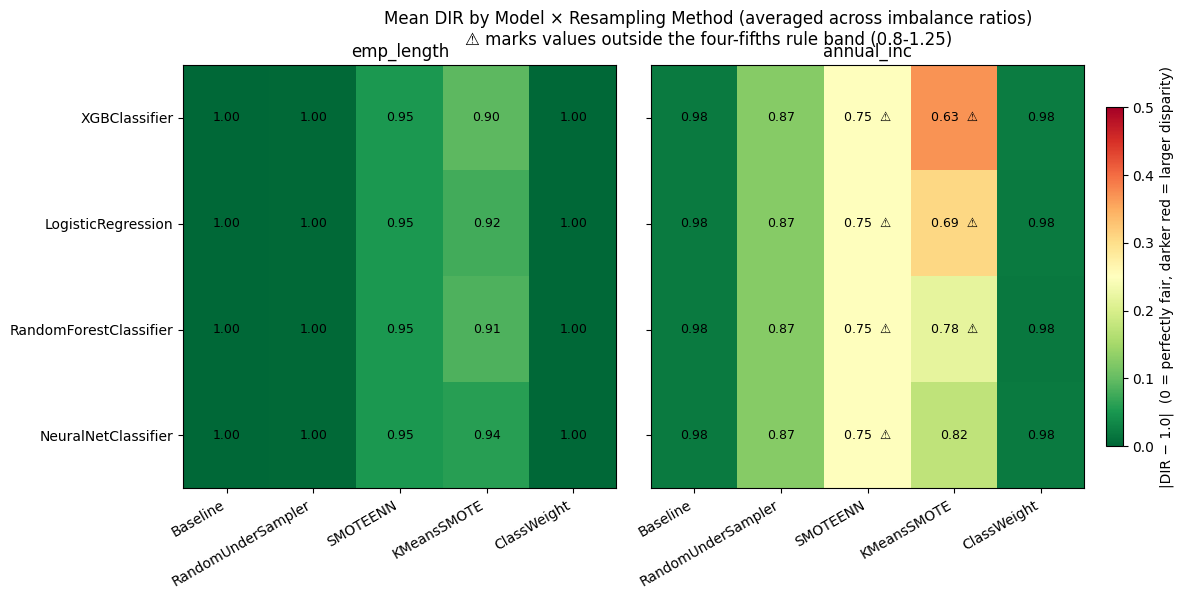

In [ ]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
fig2.subplots_adjust(wspace=0.08)
 
for idx, (ax, feature) in enumerate(zip(axes2, list(DIR_GROUP_SPECS.keys()))):
    sub = fairness_results_df[fairness_results_df["Feature"] == feature]
    pivot = (
        sub.pivot_table(index="Model", columns="Sampler", values="DIR", aggfunc="mean")
           .reindex(index=models, columns=unique_samplers)
    )
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", vmin=0.5, vmax=1.5, aspect="auto")
 
    dist = np.abs(pivot.values - 1.0)
    im = ax.imshow(dist, cmap="RdYlGn_r", vmin=0, vmax=0.5, aspect="auto")
 
    ax.set_xticks(range(len(unique_samplers)))
    ax.set_xticklabels(unique_samplers, rotation=30, ha="right")
    ax.set_yticks(range(len(models)))
    if idx == 0:
        ax.set_yticklabels(models)
    else:
        ax.tick_params(labelleft=False)
    ax.set_title(feature)
 
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            flag = "  \u26A0" if (val < 0.8 or val > 1.25) else ""
            ax.text(j, i, f"{val:.2f}{flag}", ha="center", va="center",
                     fontsize=9, color="black")
 
cbar = fig2.colorbar(im, ax=axes2, shrink=0.8, pad=0.02)
cbar.set_label("|DIR − 1.0|  (0 = perfectly fair, darker red = larger disparity)")
fig2.suptitle("Mean DIR by Model × Resampling Method (averaged across imbalance ratios)\n"
              "\u26A0 marks values outside the four-fifths rule band (0.8-1.25)", fontsize=12)
plt.show()

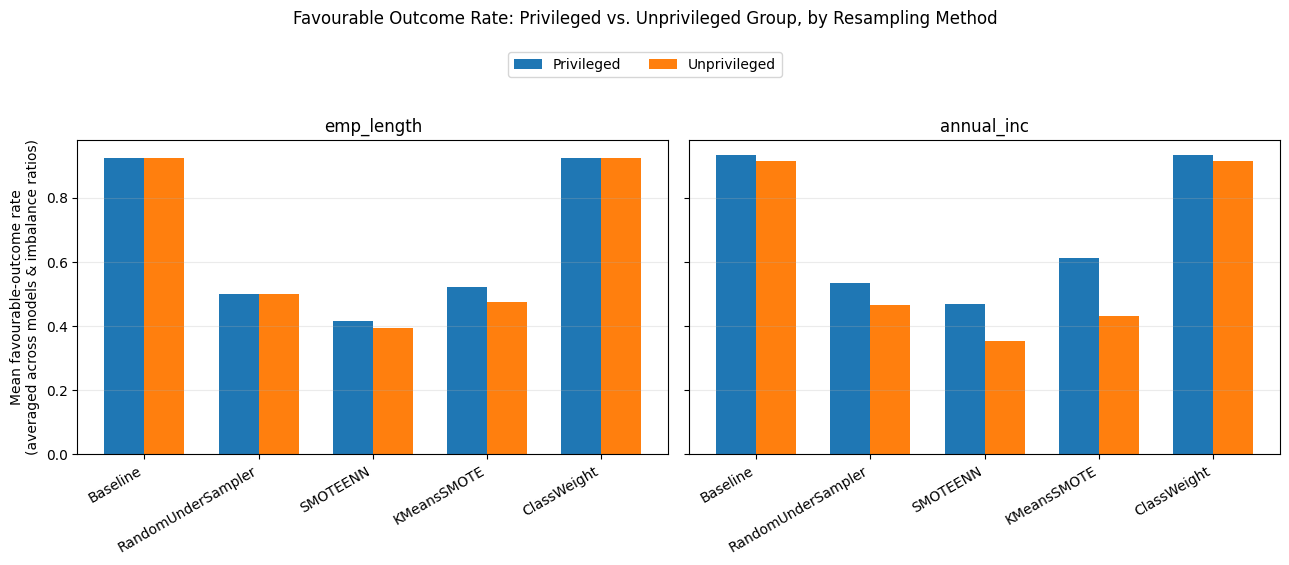

In [ ]:
rate_df = fairness_results_df.copy()
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
width = 0.35
 
for ax, feature in zip(axes3, list(DIR_GROUP_SPECS.keys())):
    sub = rate_df[rate_df["Feature"] == feature]
    grp = sub.groupby(["Sampler", "Role"])["favourable_label_rate"].mean().unstack("Role")
    grp = grp.reindex(unique_samplers)
 
    x = np.arange(len(unique_samplers))
    ax.bar(x - width/2, grp["privileged"], width, label="Privileged", color="tab:blue")
    ax.bar(x + width/2, grp["unprivileged"], width, label="Unprivileged", color="tab:orange")
 
    ax.set_xticks(x)
    ax.set_xticklabels(unique_samplers, rotation=30, ha="right")
    ax.set_title(feature)
    ax.grid(axis="y", alpha=0.25)
 
axes3[0].set_ylabel("Mean favourable-outcome rate\n(averaged across models & imbalance ratios)")
handles, labels = axes3[0].get_legend_handles_labels()
fig3.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))
fig3.suptitle("Favourable Outcome Rate: Privileged vs. Unprivileged Group, by Resampling Method", y=1.12)
fig3.tight_layout()
plt.show()

## 7. Constrained Adversarial Attacks

This chapter evaluates the third part of the audit: adversarial robustness. The goal is to test whether actual defaulters can change a small number of realistic application features to avoid being detected by the model. These attacks are evaluated across the different models, resampling strategies, and imbalance ratios.

Both attacks are black box attacks. This means that they only use the model’s output score, namely the predicted probability of default. They do not require access to the model parameters, architecture, or analytical gradients. This is important for this study, because random forest and XGBoost do not provide gradients in the same way as the neural network. Therefore, the attack method must work in the same way across all four models.


### 7.1 Threat Model and Feasibility Constraints

Two black box attacks are used in this chapter. The first is a genetic population based search, PermuteAttack, which is explained in Section 7.2. The second is ZOO, a local search method guided by finite difference gradient estimates, explained in Section 7.3. Since these attacks search for adversarial examples in different ways, agreement between them is informative. If both attacks expose similar weaknesses for the same model, resampling strategy, and imbalance ratio, this gives stronger evidence that the vulnerability is real.

The attack is restricted to feasible borrower interventions. Only `loan_amnt`, `annual_inc`, and `revol_bal` are treated as directly mutable. These are variables an applicant could realistically try to change, for example by requesting a lower loan amount, reporting a different income, or reducing revolving balance. Variables that depend on these features, such as `installment`, debt to income ratio, and revolving utilisation, are recalculated after each intervention. They are not changed independently.

This constraint is important for realism. If `loan_amnt` changes but `installment` remains the same, the resulting observation would be internally inconsistent and would not represent a realistic loan application. This would overstate the model’s vulnerability. Recalculating dependent variables keeps the adversarial examples coherent and follows the same logic as the post processing step used in the original PermuteAttack approach, where conditional feature relationships are preserved after the attack.


**Why only correctly classified true defaults.** The attacks are only evaluated on held-out observations that are true defaults and that the original model correctly classifies as defaults before the attack. This makes the threat model clear. The question is whether a borrower who will actually default can change a small number of application features to avoid detection by a model that would otherwise reject or flag them.

This is the most relevant adversarial case for a lender, because it represents evasion of a correct high-risk decision. Attacking observations that are already misclassified would not reveal a new weakness, since the model already failed before any manipulation. Attacking non-defaulters is also less relevant, because these borrowers are already the favourable class and their changes would mainly strengthen a correct positive case.


#### 7.1.1 Attack Constants

This cell defines the main settings used for the adversarial attacks. It fixes the number of attack cases evaluated for each configuration, the maximum number of features an attacker is allowed to change, and the allowed action space for each mutable feature. For every feature, the direction of change and the maximum relative change are specified.


In [ ]:
RANDOM_STATE = 42
DEFAULT_CLASS = 1

N_ATTACK_CASES = 100

# This is meaningful because there are three mutable features.
MAX_CHANGED_ACTIONS = 2

ACTION_SPECS = {
    "loan_amnt": {
        "direction": "decrease",
        "max_change": 0.25,
    },
    "annual_inc": {
        "direction": "increase",
        "max_change": 0.10,
    },
    "revol_bal": {
        "direction": "decrease",
        "max_change": 0.25,
    },
}

LOG_FEATURES = {
    "annual_inc",
    "revol_bal",
}

LOWER_Q = 0.01
UPPER_Q = 0.99

GA_POP_SIZE = 50
GA_GENERATIONS = 100
GA_RESTARTS = 5
GA_MUTATION_PROB = 0.20
GA_MUTATION_SCALE = 0.15
GA_ELITE_FRAC = 0.20

ZOO_MAX_ITER = 200
ZOO_RESTARTS = 3
ZOO_LEARNING_RATE = 0.03
ZOO_FD_STEP = 0.05

PROXIMITY_PENALTY = 0.02

#### 7.1.2 Helper Functions & Feature Repair

`to_raw` and `to_model` convert the mutable monetary features between the log-transformed model space (Section 3.2) and raw dollar values; the remaining helpers extract the actionable features and their bounds.


In [ ]:
def to_raw(value, feature):
    value = float(value)
    return max(np.expm1(value), 0.0) if feature in LOG_FEATURES else value


def to_model(value, feature):
    value = max(float(value), 0.0)
    return np.log1p(value) if feature in LOG_FEATURES else value


def get_action_features(columns):
    return [feature for feature in ACTION_SPECS if feature in columns]


def project_action_vector(z):
    z = np.clip(np.asarray(z, dtype=float), 0.0, 1.0)

    active = np.flatnonzero(z > 1e-12)

    if len(active) > MAX_CHANGED_ACTIONS:
        keep = active[np.argsort(z[active])[-MAX_CHANGED_ACTIONS:]]
        mask = np.zeros(len(z), dtype=bool)
        mask[keep] = True
        z = np.where(mask, z, 0.0)

    return z


def get_bounds(x_original, X_reference, action_features):
    bounds = {}

    for feature in action_features:
        original = to_raw(x_original.iloc[0][feature], feature)

        values = X_reference[feature].astype(float).to_numpy()

        if feature in LOG_FEATURES:
            values = np.expm1(values)

        values = values[np.isfinite(values)]

        if len(values) == 0:
            bounds[feature] = (original, original)
            continue

        q_low = float(np.nanquantile(values, LOWER_Q))
        q_high = float(np.nanquantile(values, UPPER_Q))

        direction = ACTION_SPECS[feature]["direction"]
        max_change = ACTION_SPECS[feature]["max_change"]

        if direction == "increase":
            low = original
            high = min(original * (1 + max_change), q_high)

            if high < low:
                high = low

        elif direction == "decrease":
            low = max(original * (1 - max_change), q_low, 0.0)
            high = original

            if low > high:
                low = high

        bounds[feature] = (float(low), float(high))

    return bounds

`repair_features` implements the feasibility constraint of Section 7.1: after each candidate intervention, the functionally dependent features (`installment`, `dti`, `revol_util`) are recomputed from the changed values so every adversarial candidate remains internally consistent.


In [ ]:
def repair_features(x_adv, x_original):
    eps = 1e-10

    if {"loan_amnt", "installment"}.issubset(x_adv.columns):
        old_loan = max(float(x_original.iloc[0]["loan_amnt"]), eps)
        old_installment = float(x_original.iloc[0]["installment"])
        new_loan = float(x_adv.iloc[0]["loan_amnt"])

        x_adv.loc[:, "installment"] = (
            old_installment * new_loan / old_loan
        )

    if {"annual_inc", "dti"}.issubset(x_adv.columns):
        old_income = max(
            to_raw(x_original.iloc[0]["annual_inc"], "annual_inc"),
            eps,
        )

        new_income = max(
            to_raw(x_adv.iloc[0]["annual_inc"], "annual_inc"),
            eps,
        )

        old_dti = float(x_original.iloc[0]["dti"])

        x_adv.loc[:, "dti"] = max(
            0.0,
            old_dti * old_income / new_income,
        )

    if {"revol_bal", "revol_util"}.issubset(x_adv.columns):
        old_balance = to_raw(
            x_original.iloc[0]["revol_bal"],
            "revol_bal",
        )

        old_util = float(x_original.iloc[0]["revol_util"])

        if old_balance > eps and old_util > eps:
            credit_limit = old_balance / (old_util / 100.0)

            new_balance = to_raw(
                x_adv.iloc[0]["revol_bal"],
                "revol_bal",
            )

            x_adv.loc[:, "revol_util"] = np.clip(
                100.0 * new_balance / credit_limit,
                0.0,
                100.0,
            )

    return x_adv


def vector_to_instance(z, x_original, bounds, action_features):
    z_effective = project_action_vector(z)

    x_adv = x_original.copy(deep=True)

    for i, feature in enumerate(action_features):
        original = to_raw(x_original.iloc[0][feature], feature)
        low, high = bounds[feature]

        if ACTION_SPECS[feature]["direction"] == "increase":
            new_value = original + z_effective[i] * (high - original)
        else:
            new_value = original - z_effective[i] * (original - low)

        new_value = np.clip(new_value, low, high)

        x_adv.loc[:, feature] = to_model(new_value, feature)

    x_adv = repair_features(x_adv, x_original)

    return x_adv, z_effective


def default_probability_index(model):
    classes = np.asarray(model.classes_)

    matches = np.where(classes == DEFAULT_CLASS)[0]

    if len(matches) != 1:
        raise ValueError(
            f"Default class {DEFAULT_CLASS} was not found in {classes}."
        )

    return int(matches[0])


def default_probabilities(model, X):
    class_index = default_probability_index(model)
    return model.predict_proba(X)[:, class_index]


def default_probability(model, X, query_counter=None):
    if query_counter is not None:
        query_counter["count"] += 1

    return float(default_probabilities(model, X)[0])


def get_threshold(model, X_validation, y_validation):
    probabilities = default_probabilities(model, X_validation)

    precision, recall, thresholds = precision_recall_curve(
        y_validation,
        probabilities,
        pos_label=DEFAULT_CLASS,
    )

    if len(thresholds) == 0:
        return 0.50

    f1_scores = (
        2.0
        * precision[:-1]
        * recall[:-1]
        / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    )

    return float(thresholds[np.argmax(f1_scores)])


def changed_features(x_adv, x_original, action_features):
    return int(
        sum(
            abs(
                to_raw(x_adv.iloc[0][feature], feature)
                - to_raw(x_original.iloc[0][feature], feature)
            ) > 1e-8
            for feature in action_features
        )
    )



`evaluate_candidate` maps a candidate perturbation vector to a repaired instance, queries the model, and tracks the query count — the shared evaluation core used by both attacks.


In [ ]:
def evaluate_candidate(
    z,
    model,
    x_original,
    bounds,
    action_features,
    query_counter,
):
    x_adv, z_effective = vector_to_instance(
        z,
        x_original,
        bounds,
        action_features,
    )

    adversarial_probability = default_probability(
        model,
        x_adv,
        query_counter,
    )

    perturbation_cost = np.mean(np.abs(z_effective))

    score = (
        adversarial_probability
        + PROXIMITY_PENALTY * perturbation_cost
    )

    return score, adversarial_probability, x_adv, z_effective


def create_result(
    method,
    original_probability,
    adversarial_probability,
    x_original,
    x_adv,
    action_features,
    threshold,
    query_counter,
    runtime_seconds,
):
    result = {
        "Method": method,
        "Success": int(adversarial_probability < threshold),
        "Original default probability": original_probability,
        "Adversarial default probability": adversarial_probability,
        "Probability reduction": (
            original_probability - adversarial_probability
        ),
        "Changed features": changed_features(
            x_adv,
            x_original,
            action_features,
        ),
        "Queries": int(query_counter["count"]),
        "Runtime seconds": runtime_seconds,
    }

    for feature in action_features:
        before = to_raw(x_original.iloc[0][feature], feature)
        after = to_raw(x_adv.iloc[0][feature], feature)

        result[f"{feature}_before"] = before
        result[f"{feature}_after"] = after
        result[f"{feature}_relative_change"] = (
            (after - before) / before
            if before != 0
            else np.nan
        )

    return result

### 7.2 PermuteAttack

PermuteAttack was introduced by Hashemi and Fathi (2020) for credit scorecards, which makes it close to the setting of this study. The method is designed for tabular credit data with discrete and categorical variables. This is important because many gradient based attacks were originally developed for continuous image data and can produce unrealistic observations when applied directly to structured borrower data.

PermuteAttack uses a gradient free genetic search. It starts with a population of possible feature changes and improves these candidates over several generations. Candidates are preferred when they succeed in changing the model’s decision while keeping the number and size of feature changes small. Since the method does not require gradients, it can be applied to all classifiers in this study without modification. This is why it is used here instead of a gradient based method that would mainly be suitable for the neural network.

The cell below implements the constrained genetic search.


In [ ]:
def permute_attack(
    model,
    x_original,
    X_reference,
    action_features,
    threshold,
    seed=RANDOM_STATE,
):
    rng = np.random.default_rng(seed)

    start = time.perf_counter()
    query_counter = {"count": 0}

    bounds = get_bounds(
        x_original,
        X_reference,
        action_features,
    )

    original_probability = default_probability(
        model,
        x_original,
        query_counter,
    )

    d = len(action_features)

    best_score = np.inf
    best_probability = original_probability
    best_x_adv = x_original.copy(deep=True)

    n_elite = max(
        2,
        int(GA_POP_SIZE * GA_ELITE_FRAC),
    )

    for _ in range(GA_RESTARTS):
        population = rng.uniform(
            low=0.0,
            high=1.0,
            size=(GA_POP_SIZE, d),
        )

        population[0] = np.zeros(d)

        population = np.asarray(
            [project_action_vector(z) for z in population]
        )

        for _ in range(GA_GENERATIONS):
            evaluations = []

            for z in population:
                score, probability, x_adv, z_effective = evaluate_candidate(
                    z=z,
                    model=model,
                    x_original=x_original,
                    bounds=bounds,
                    action_features=action_features,
                    query_counter=query_counter,
                )

                evaluations.append(
                    {
                        "score": score,
                        "probability": probability,
                        "x_adv": x_adv,
                        "z": z_effective,
                    }
                )

            evaluations.sort(key=lambda item: item["score"])

            if evaluations[0]["score"] < best_score:
                best_score = evaluations[0]["score"]
                best_probability = evaluations[0]["probability"]
                best_x_adv = evaluations[0]["x_adv"].copy(deep=True)

            successful = [
                item
                for item in evaluations
                if item["probability"] < threshold
            ]

            if successful:
                selected = min(
                    successful,
                    key=lambda item: item["score"],
                )

                return create_result(
                    method="PermuteAttack-inspired GA",
                    original_probability=original_probability,
                    adversarial_probability=selected["probability"],
                    x_original=x_original,
                    x_adv=selected["x_adv"],
                    action_features=action_features,
                    threshold=threshold,
                    query_counter=query_counter,
                    runtime_seconds=time.perf_counter() - start,
                )

            elites = np.asarray(
                [
                    item["z"]
                    for item in evaluations[:n_elite]
                ]
            )

            children = [elite.copy() for elite in elites]

            while len(children) < GA_POP_SIZE:
                parent_1 = elites[
                    rng.integers(0, len(elites))
                ]

                parent_2 = elites[
                    rng.integers(0, len(elites))
                ]

                crossover_mask = rng.random(d) < 0.5

                child = np.where(
                    crossover_mask,
                    parent_1,
                    parent_2,
                )

                mutation_mask = rng.random(d) < GA_MUTATION_PROB

                child[mutation_mask] += rng.normal(
                    loc=0.0,
                    scale=GA_MUTATION_SCALE,
                    size=mutation_mask.sum(),
                )

                if rng.random() < 0.30:
                    child[rng.integers(0, d)] = 0.0

                children.append(
                    project_action_vector(child)
                )

            population = np.asarray(children)

    return create_result(
        method="PermuteAttack-inspired GA",
        original_probability=original_probability,
        adversarial_probability=best_probability,
        x_original=x_original,
        x_adv=best_x_adv,
        action_features=action_features,
        threshold=threshold,
        query_counter=query_counter,
        runtime_seconds=time.perf_counter() - start,
    )

### 7.3 ZOO

ZOO, or Zeroth Order Optimization, was introduced by Chen et al. (2017) as a black box attack for neural networks. Instead of using the true gradients from backpropagation, it estimates the gradient by repeatedly querying the model. For each mutable feature, the model is evaluated after making a small positive and negative change. The difference between these two outputs is then used as an approximation of the feature’s gradient.

This estimated gradient guides the attack in the same way that a real gradient would guide a white box attack. Although ZOO was originally developed for image data, where estimating gradients can require many model queries, it is more practical in this study. The credit dataset only has a small number of mutable features, so the number of required query pairs remains limited.

The cell below implements the constrained finite difference attack.


In [ ]:
def zoo_attack(
    model,
    x_original,
    X_reference,
    action_features,
    threshold,
    seed=RANDOM_STATE
):
    rng = np.random.default_rng(seed)

    start = time.perf_counter()
    query_counter = {"count": 0}

    bounds = get_bounds(
        x_original,
        X_reference,
        action_features,
    )

    original_probability = default_probability(
        model,
        x_original,
        query_counter,
    )

    d = len(action_features)

    best_score = np.inf
    best_probability = original_probability
    best_x_adv = x_original.copy(deep=True)

    for restart in range(ZOO_RESTARTS):
        if restart == 0:
            z = np.zeros(d)
        else:
            z = rng.uniform(
                low=0.0,
                high=0.25,
                size=d,
            )

        z = project_action_vector(z)

        m = np.zeros(d)
        v = np.zeros(d)

        current_score, current_probability, current_x_adv, z = (
            evaluate_candidate(
                z=z,
                model=model,
                x_original=x_original,
                bounds=bounds,
                action_features=action_features,
                query_counter=query_counter,
            )
        )

        if current_score < best_score:
            best_score = current_score
            best_probability = current_probability
            best_x_adv = current_x_adv.copy(deep=True)

        for iteration in range(1, ZOO_MAX_ITER + 1):
            gradient = np.zeros(d)

            for j in range(d):
                z_plus = z.copy()
                z_minus = z.copy()

                z_plus[j] = min(
                    1.0,
                    z_plus[j] + ZOO_FD_STEP,
                )

                z_minus[j] = max(
                    0.0,
                    z_minus[j] - ZOO_FD_STEP,
                )

                f_plus, _, _, _ = evaluate_candidate(
                    z=z_plus,
                    model=model,
                    x_original=x_original,
                    bounds=bounds,
                    action_features=action_features,
                    query_counter=query_counter,
                )

                f_minus, _, _, _ = evaluate_candidate(
                    z=z_minus,
                    model=model,
                    x_original=x_original,
                    bounds=bounds,
                    action_features=action_features,
                    query_counter=query_counter,
                )

                denominator = max(
                    z_plus[j] - z_minus[j],
                    1e-8,
                )

                gradient[j] = (
                    f_plus - f_minus
                ) / denominator

            beta_1 = 0.90
            beta_2 = 0.999

            m = beta_1 * m + (1.0 - beta_1) * gradient
            v = beta_2 * v + (1.0 - beta_2) * gradient**2

            m_hat = m / (1.0 - beta_1**iteration)
            v_hat = v / (1.0 - beta_2**iteration)

            proposal = z - ZOO_LEARNING_RATE * m_hat / (
                np.sqrt(v_hat) + 1e-8
            )

            proposal = project_action_vector(proposal)

            (
                proposal_score,
                proposal_probability,
                proposal_x_adv,
                proposal_z,
            ) = evaluate_candidate(
                z=proposal,
                model=model,
                x_original=x_original,
                bounds=bounds,
                action_features=action_features,
                query_counter=query_counter,
            )

            if proposal_score <= current_score:
                z = proposal_z
                current_score = proposal_score
                current_probability = proposal_probability
                current_x_adv = proposal_x_adv

            if current_score < best_score:
                best_score = current_score
                best_probability = current_probability
                best_x_adv = current_x_adv.copy(deep=True)

            if current_probability < threshold:
                return create_result(
                    method="ZOO-inspired finite difference",
                    original_probability=original_probability,
                    adversarial_probability=current_probability,
                    x_original=x_original,
                    x_adv=current_x_adv,
                    action_features=action_features,
                    threshold=threshold,
                    query_counter=query_counter,
                    runtime_seconds=time.perf_counter() - start,
                )

    return create_result(
        method="ZOO-inspired finite difference",
        original_probability=original_probability,
        adversarial_probability=best_probability,
        x_original=x_original,
        x_adv=best_x_adv,
        action_features=action_features,
        threshold=threshold,
        query_counter=query_counter,
        runtime_seconds=time.perf_counter() - start,
    )

### 7.4 Attack Analysis & Robustness Findings

For every configuration, the **attack success rate** (fraction of already-flagged defaulters pushed back below the decision threshold), the **number of features changed**, the **probability reduction** achieved, and the attacker **effort** (model queries and runtime) are recorded. The attacks are executed first, then analysed from several angles.


#### 7.4.1 Attack Execution

The attack targets are the four models with their tuned configurations from Section 5.4.


In [ ]:
xgb_attack_params = config["XGBClassifier"].copy()
xgb_attack_params["random_state"] = RANDOM_STATE
xgb_attack_params["eval_metric"] = "logloss"

lr_attack_params = config["LogisticRegression"].copy()
lr_attack_params["random_state"] = RANDOM_STATE

rf_attack_params = config["RandomForestClassifier"].copy()
rf_attack_params["random_state"] = RANDOM_STATE
rf_attack_params["n_jobs"] = -1

ATTACK_MODELS = [
    XGBClassifier(**xgb_attack_params),
    LogisticRegression(**lr_attack_params),
    RandomForestClassifier(**rf_attack_params),
    net_clf,
]

attack_results = []
attack_errors = []

required_attack_columns = [
    "loan_amnt",
    "annual_inc",
    "revol_bal",
    "installment",
    "dti",
    "revol_util",
]

configuration_number = 0

The main attack loop: for each imbalance level, the data is split into train/validation/test, each (model, sampler) combination is fitted, the correctly-classified true defaults are selected as attack cases, and both attacks are run against each case.


In [ ]:
for fraction, (X_full, y_full) in datasets.items():
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_full,
        y_full,
        test_size=0.20,
        stratify=y_full,
        random_state=RANDOM_STATE,
    )

    X_train, X_validation, y_train, y_validation = train_test_split(
        X_train_val,
        y_train_val,
        test_size=0.20,
        stratify=y_train_val,
        random_state=RANDOM_STATE,
    )

    action_features = get_action_features(X_train.columns)

    if len(action_features) != len(ACTION_SPECS):
        raise ValueError(
            "One or more configured action features are missing."
        )

    available_required_columns = [
        column
        for column in required_attack_columns
        if column in X_test.columns
    ]

    for base_model in ATTACK_MODELS:
        model_name = base_model.__class__.__name__

        for sampler_name, sampler in samplers.items():
            configuration_number += 1

            print(
                f"Running: ratio={fraction}, "
                f"model={model_name}, "
                f"sampler={sampler_name}"
            )

            try:
                y_fit = y_train.to_numpy().astype(np.int64)

                estimator = apply_class_weight(
                    clone(base_model),
                    sampler_name,
                    y_fit,
                )

                sampler_instance = (
                    clone(sampler)
                    if sampler is not None
                    else None
                )

                pipeline = build_pipeline(
                    estimator,
                    sampler_instance,
                )

                pipeline.fit(X_train, y_fit)

                threshold = get_threshold(
                    pipeline,
                    X_validation,
                    y_validation,
                )

                test_default_probabilities = default_probabilities(
                    pipeline,
                    X_test,
                )

                candidate_mask = (
                    (y_test.to_numpy() == DEFAULT_CLASS)
                    & (test_default_probabilities >= threshold)
                )

                if available_required_columns:
                    complete_mask = (
                        X_test[available_required_columns]
                        .notna()
                        .all(axis=1)
                        .to_numpy()
                    )

                    candidate_mask &= complete_mask

                candidates = X_test.loc[candidate_mask].copy()

                if len(candidates) == 0:
                    print("No eligible attack cases.")
                    continue

                candidates = candidates.sample(
                    n=min(N_ATTACK_CASES, len(candidates)),
                    random_state=RANDOM_STATE + configuration_number,
                )

                for case_number, (_, row) in enumerate(
                    candidates.iterrows()
                ):
                    x_original = row.to_frame().T
                    x_original = x_original.reindex(
                        columns=X_train.columns
                    )

                    case_seed = (
                        RANDOM_STATE
                        + 100000 * configuration_number
                        + case_number
                    )

                    ga_result = permute_attack(
                        model=pipeline,
                        x_original=x_original,
                        X_reference=X_train,
                        action_features=action_features,
                        threshold=threshold,
                        seed=case_seed,
                    )

                    ga_result.update(
                        {
                            "Imbalance ratio": fraction,
                            "Model": model_name,
                            "Sampler": sampler_name,
                            "Case": case_number,
                            "Threshold": threshold,
                        }
                    )

                    attack_results.append(ga_result)

                    zoo_result = zoo_attack(
                        model=pipeline,
                        x_original=x_original,
                        X_reference=X_train,
                        action_features=action_features,
                        threshold=threshold,
                        seed=case_seed + 50000,
                    )

                    zoo_result.update(
                        {
                            "Imbalance ratio": fraction,
                            "Model": model_name,
                            "Sampler": sampler_name,
                            "Case": case_number,
                            "Threshold": threshold,
                        }
                    )

                    attack_results.append(zoo_result)

            except Exception as error:
                attack_errors.append(
                    {
                        "Imbalance ratio": fraction,
                        "Model": model_name,
                        "Sampler": sampler_name,
                        "Error": str(error),
                    }
                )

                print(
                    f"FAILED: ratio={fraction}, "
                    f"model={model_name}, "
                    f"sampler={sampler_name}\n{error}"
                )

The per-case records are assembled into a results table and aggregated into a per-configuration summary.


In [ ]:
attack_results = pd.DataFrame(attack_results)
attack_errors = pd.DataFrame(attack_errors)

if attack_results.empty:
    raise RuntimeError(
        "No attack results were produced. "
        "Inspect attack_errors for details."
    )

attack_summary = (
    attack_results
    .groupby(
        [
            "Imbalance ratio",
            "Model",
            "Sampler",
            "Method",
        ],
        as_index=False,
    )
    .agg(
        Attack_Success_Rate=("Success", "mean"),
        Mean_Probability_Reduction=(
            "Probability reduction",
            "mean",
        ),
        Mean_Changed_Features=(
            "Changed features",
            "mean",
        ),
        Median_Queries=("Queries", "median"),
        Median_Runtime_Seconds=(
            "Runtime seconds",
            "median",
        ),
        N_Attacked=("Success", "count"),
    )
)

display(attack_summary)

#### 7.4.2 Attack Success Rate vs Imbalance Ratio


Any attack errors are displayed, and the results, summary, and error tables are written to disk.


In [ ]:
if not attack_errors.empty:
    display(attack_errors)

attack_results.to_csv(
    "outputs/attack_results.csv",
    index=False,
)

attack_summary.to_csv(
    "outputs/attack_summary.csv",
    index=False,
)

attack_errors.to_csv(
    "outputs/attack_errors.csv",
    index=False,
)

In [ ]:
# The attack results computed on the HPC cluster are read back in.
attack_results = pd.read_csv("outputs/adversarial_attack_results.csv")

`plot_attack_success` plots the attack success rate against the imbalance ratio per sampler and model, for the genetic attack (GA, solid) and ZOO (dashed) side by side.


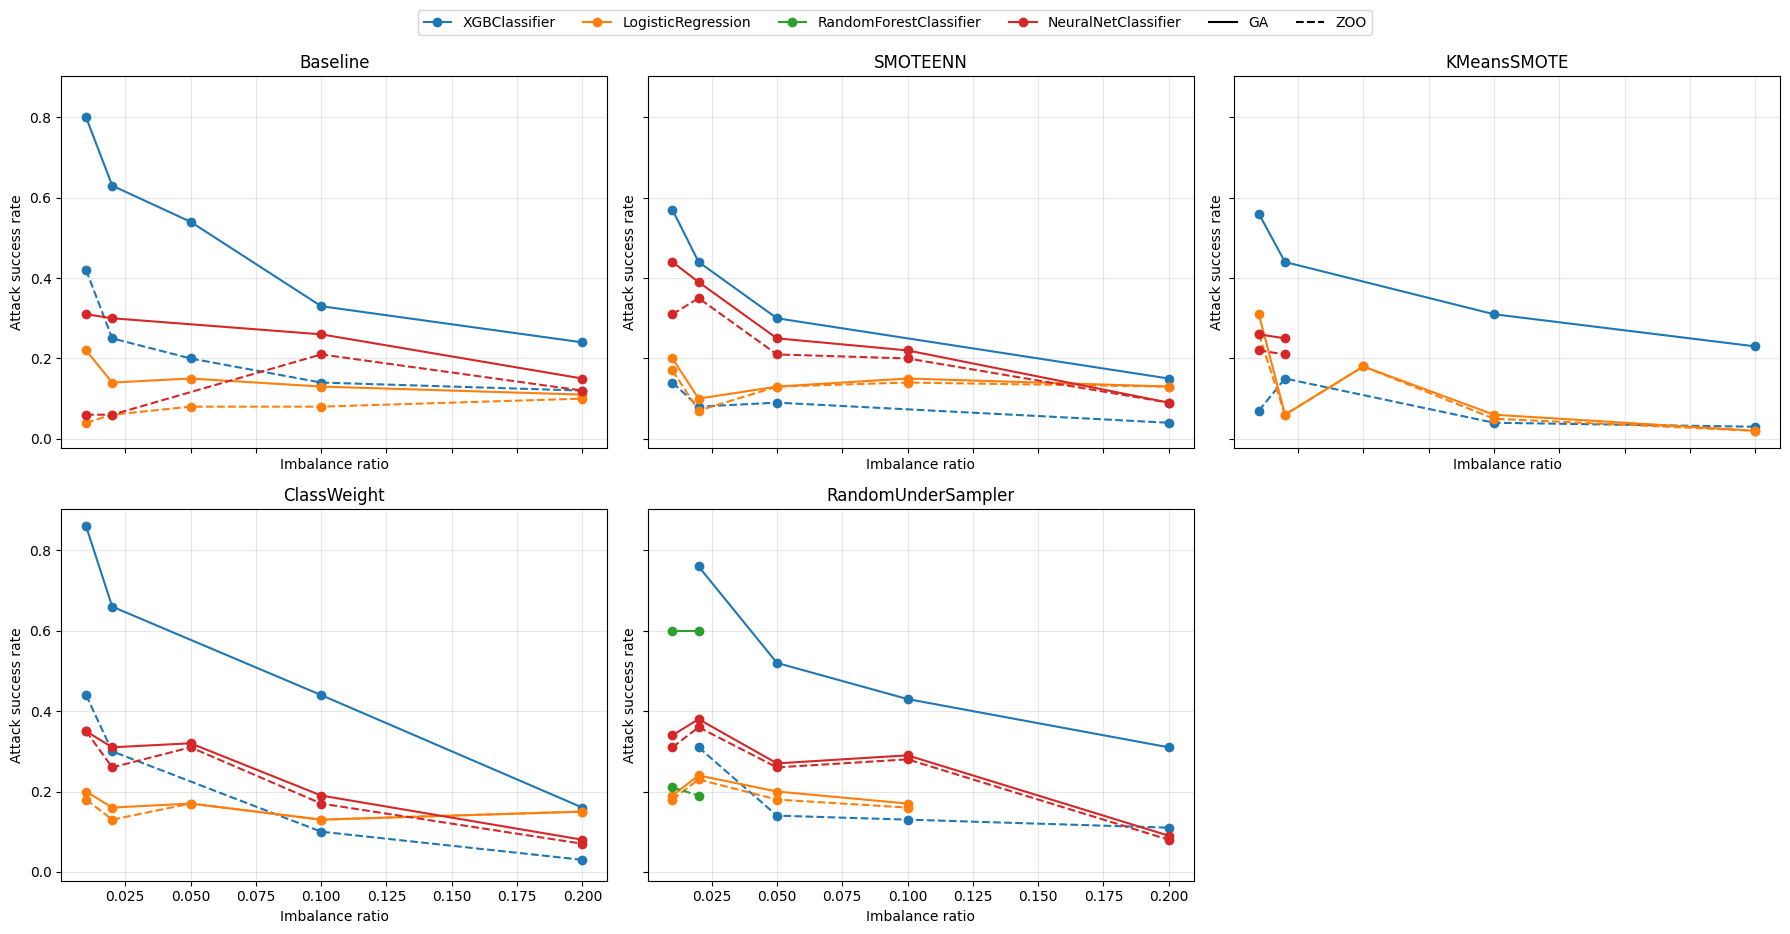

In [ ]:
def plot_attack_success(adf: pd.DataFrame, outputs_dir: str):
    ir_col = "Imbalance ratio"
    
    method_styles = [("GA", "-"), ("ZOO", "--")]
    methods = [
        (name, ls) for name, ls in method_styles
        if f"Attack success rate ({name})" in adf.columns
    ]
    if not methods:  
        methods = [("", "-")]

    samplers = adf["Sampler"].unique()
    models = list(adf["Model"].unique())
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    model_color = {m: color_cycle[i % len(color_cycle)] for i, m in enumerate(models)}

    n = len(samplers)
    ncols = 3
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()
    for ax, sampler in zip(axes, samplers):
        sub = adf[adf["Sampler"] == sampler]
        for model in models:
            m = sub[sub["Model"] == model].sort_values(ir_col)
            if m.empty:
                continue
            for name, ls in methods:
                col = f"Attack success rate ({name})" if name else "Attack success rate"
                if col in m:
                    ax.plot(m[ir_col], m[col], marker="o", linestyle=ls, color=model_color[model])
        ax.set_title(sampler)
        ax.set_xlabel("Imbalance ratio")
        ax.set_ylabel("Attack success rate")
        ax.grid(True, alpha=0.3)
    for ax in axes[n:]:
        ax.set_visible(False)

    
    from matplotlib.lines import Line2D
    model_handles = [Line2D([0], [0], color=model_color[m], marker="o", label=m) for m in models]
    method_handles = [
        Line2D([0], [0], color="black", linestyle=ls, label=name)
        for name, ls in methods if name
    ]
    handles = model_handles + method_handles
    fig.legend(handles, [h.get_label() for h in handles],
               loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 1.04))
    fig.tight_layout()
    fig.savefig('outputs/attack_success_rate.png', bbox_inches="tight", dpi=150)
    plt.show()

plot_attack_success(attack_results, outputs_dir=".")

In [ ]:

ir_col   = "Imbalance ratio"
METHODS  = ["GA", "ZOO"]

MODEL_ORDER   = ["XGBClassifier", "LogisticRegression",
                 "RandomForestClassifier", "NeuralNetClassifier"]
SAMPLER_ORDER = ["Baseline", "ClassWeight", "RandomUnderSampler",
                 "SMOTEENN", "KMeansSMOTE"]

def _order(values, preferred):
    present = list(pd.unique(values))
    return [v for v in preferred if v in present] + [v for v in present if v not in preferred]

attack_models   = _order(attack_results["Model"], MODEL_ORDER)
attack_samplers = _order(attack_results["Sampler"], SAMPLER_ORDER)

asr_cols  = {m: f"Attack success rate ({m})"   for m in METHODS}
feat_cols = {m: f"Mean changed features ({m})" for m in METHODS}
q_cols    = {m: f"Median queries ({m})"        for m in METHODS}

_cmap = plt.cm.tab10
sampler_color = {s: _cmap(i % 10) for i, s in enumerate(attack_samplers)}

#### 7.4.3 Vulnerability Heatmaps (Model × Sampler)

Averaging the attack success rate across imbalance ratios gives a compact view of which classifiers are easiest to fool, and under which resampling strategy. Brighter cells are more vulnerable; grey cells were not evaluated.


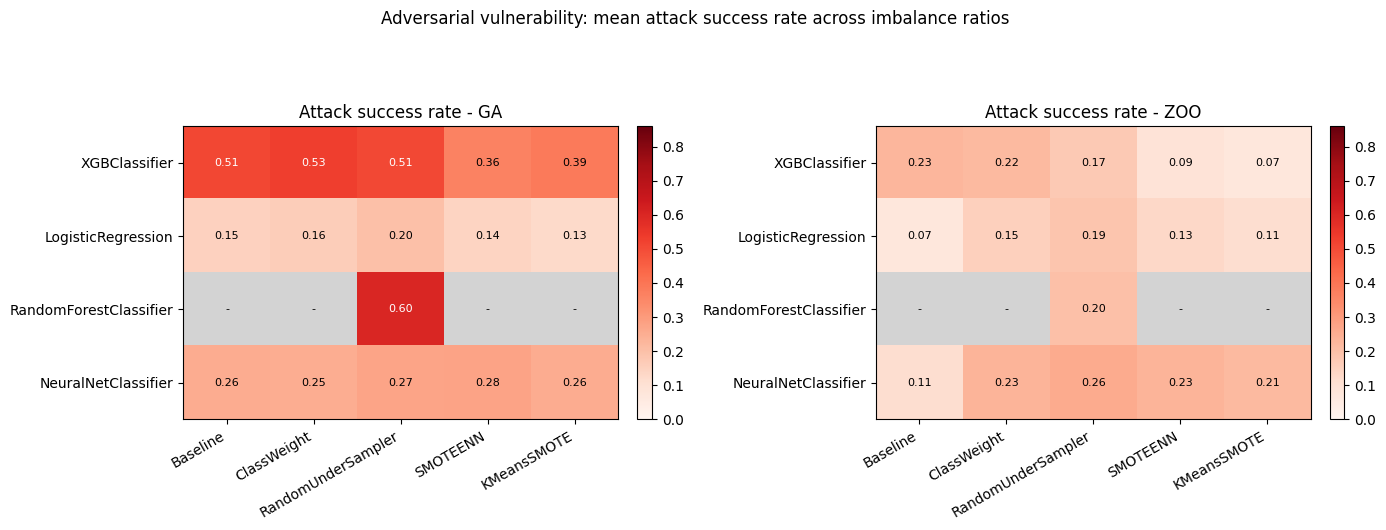

In [ ]:
fig, axes = plt.subplots(1, len(METHODS), figsize=(7 * len(METHODS), 5))
axes = np.atleast_1d(axes).flatten()
vmax = max(attack_results[asr_cols[m]].max() for m in METHODS)

for ax, method in zip(axes, METHODS):
    piv = (attack_results.groupby(["Model", "Sampler"])[asr_cols[method]].mean()
           .unstack("Sampler").reindex(index=attack_models, columns=attack_samplers))
    cmap = plt.cm.Reds.copy(); cmap.set_bad("lightgrey")
    im = ax.imshow(np.ma.masked_invalid(piv.values), cmap=cmap,
                   aspect="auto", vmin=0, vmax=vmax)
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_title(f"Attack success rate - {method}")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            ax.text(j, i, "-" if np.isnan(v) else f"{v:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if (not np.isnan(v) and v > 0.55 * vmax) else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Adversarial vulnerability: mean attack success rate across imbalance ratios\n", y=1.05)
fig.tight_layout()
fig.savefig("outputs/attack_vulnerability_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

#### 7.4.4 Robustness by Resampling Strategy

Aggregating over models and imbalance ratios, the mean attack success rate of each sampler is compared for both attacks (lower = more robust).


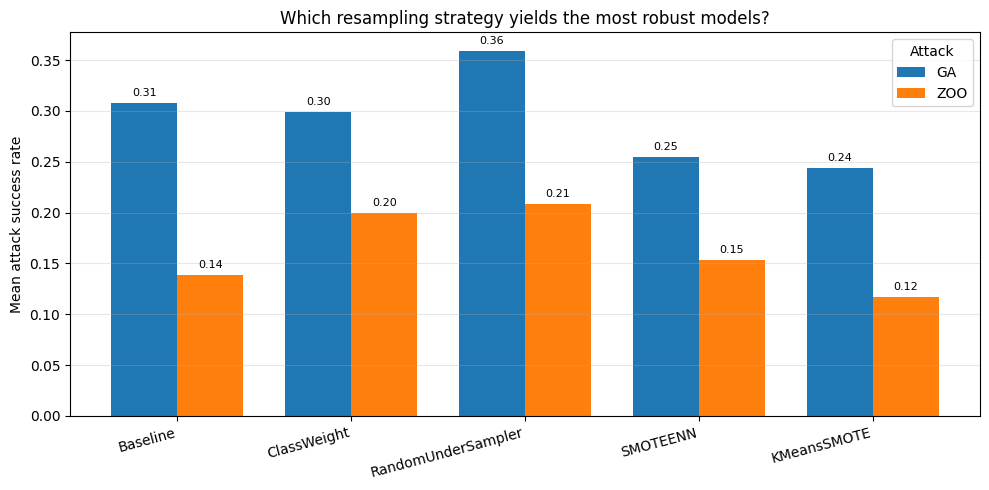

In [ ]:
means = {m: attack_results.groupby("Sampler")[asr_cols[m]].mean().reindex(attack_samplers)
         for m in METHODS}

x = np.arange(len(attack_samplers)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
for k, method in enumerate(METHODS):
    ax.bar(x + (k - 0.5) * w, means[method].values, w, label=method)
    for xi, v in zip(x, means[method].values):
        if not np.isnan(v):
            ax.text(xi + (k - 0.5) * w, v + 0.005, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(attack_samplers, rotation=15, ha="right")
ax.set_ylabel("Mean attack success rate")
ax.set_title("Which resampling strategy yields the most robust models?")
ax.legend(title="Attack"); ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("outputs/attack_robustness_by_sampler.png", bbox_inches="tight", dpi=150)
plt.show()

#### 7.4.5 Robustness vs Predictive Performance

Finally we connect Section 6 (clean performance) with Section 8 (robustness): each point is a `(model, sampler, imbalance ratio)` cell, plotting its PR-AUC against its GA attack success rate. The negative correlation points to a mild **trade-off in the imbalance dimension** - the harder, extreme-imbalance settings are both low-PR-AUC *and* highly attackable, whereas the higher-minority settings that rank defaulters better also expose a somewhat smaller attack surface.

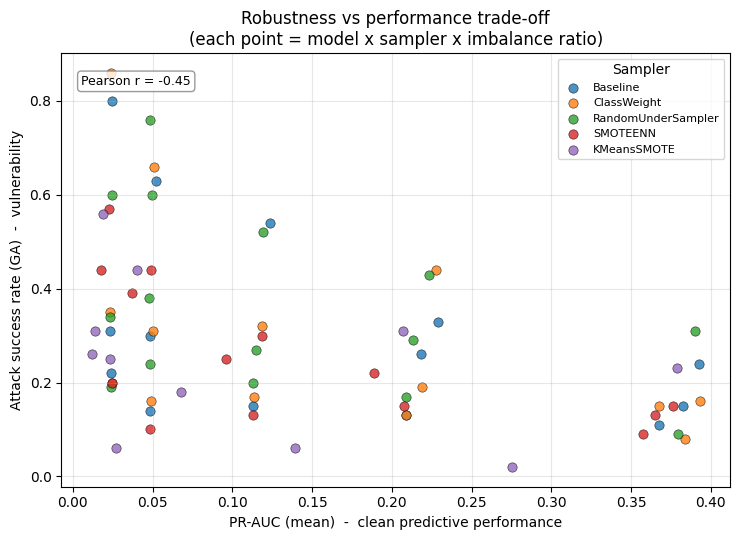

In [ ]:
# Join clean performance (Section 6) with adversarial robustness (Section 8)
_mr = pd.read_csv("outputs/model_results.csv")
_merged = attack_results.merge(
    _mr[["Model", "Sampler", ir_col, "PR-AUC (mean)"]],
    on=["Model", "Sampler", ir_col], how="inner")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for s in attack_samplers:
    sub = _merged[_merged["Sampler"] == s]
    if sub.empty:
        continue
    ax.scatter(sub["PR-AUC (mean)"], sub[asr_cols["GA"]], color=sampler_color[s],
               label=s, s=45, alpha=0.8, edgecolor="k", linewidth=0.4)

ax.set_xlabel("PR-AUC (mean)  -  clean predictive performance")
ax.set_ylabel("Attack success rate (GA)  -  vulnerability")
ax.set_title("Robustness vs performance trade-off\n(each point = model x sampler x imbalance ratio)")
ax.legend(title="Sampler", fontsize=8); ax.grid(True, alpha=0.3)

if len(_merged) > 2:
    r = np.corrcoef(_merged["PR-AUC (mean)"], _merged[asr_cols["GA"]])[0, 1]
    ax.annotate(f"Pearson r = {r:.2f}", xy=(0.03, 0.95), xycoords="axes fraction",
                fontsize=9, va="top",
                bbox=dict(boxstyle="round", fc="white", ec="grey", alpha=0.8))

fig.tight_layout()
fig.savefig("outputs/attack_robustness_vs_performance.png", bbox_inches="tight", dpi=150)
plt.show()

#### 7.4.6 Summary: Best & Most Adversarially Hardened Resampling per Model

Bringing Sections 6 and 8 together, the table below reports for **each model**:

- the **best performing** resampling strategy - the sampler with the highest mean PR-AUC (averaged over all imbalance ratios), and
- the **most adversarially hardened** resampling strategy - the sampler with the lowest mean attack success rate (averaging the GA and ZOO attacks over all imbalance ratios; lower = harder to attack).

In [ ]:
# Per-model summary: best predictive vs most adversarially hardened resampling
_perf = pd.read_csv("outputs/model_results.csv")
_atk  = pd.read_csv("outputs/adversarial_attack_results.csv")

PERF_METRIC     = "PR-AUC (mean)"
ASR_GA, ASR_ZOO = "Attack success rate (GA)", "Attack success rate (ZOO)"

# Best performing sampler per model: highest PR-AUC averaged over imbalance ratios
_perf_ms = _perf.groupby(["Model", "Sampler"])[PERF_METRIC].mean().reset_index()
_best = (_perf_ms.loc[_perf_ms.groupby("Model")[PERF_METRIC].idxmax()]
         .rename(columns={"Sampler": "Best performing sampler", PERF_METRIC: "Mean PR-AUC"}))

# Most hardened sampler per model: lowest attack success rate (mean of GA and ZOO)
_atk = _atk.copy()
_atk["Mean ASR"] = _atk[[ASR_GA, ASR_ZOO]].mean(axis=1)
_atk_ms = _atk.groupby(["Model", "Sampler"])[["Mean ASR", ASR_GA, ASR_ZOO]].mean().reset_index()
_robust = (_atk_ms.loc[_atk_ms.groupby("Model")["Mean ASR"].idxmin()]
           .rename(columns={"Sampler": "Most hardened sampler",
                            "Mean ASR": "Mean ASR (GA+ZOO)",
                            ASR_GA: "ASR (GA)", ASR_ZOO: "ASR (ZOO)"}))

summary = (_best[["Model", "Best performing sampler", "Mean PR-AUC"]]
           .merge(_robust[["Model", "Most hardened sampler",
                           "Mean ASR (GA+ZOO)", "ASR (GA)", "ASR (ZOO)"]],
                  on="Model", how="outer"))

_model_order = ["XGBClassifier", "LogisticRegression",
                "RandomForestClassifier", "NeuralNetClassifier"]
_order = ([m for m in _model_order if m in summary["Model"].values]
          + [m for m in summary["Model"].values if m not in _model_order])
summary["Model"] = pd.Categorical(summary["Model"], _order)
summary = summary.sort_values("Model").reset_index(drop=True)
for _c in ["Mean PR-AUC", "Mean ASR (GA+ZOO)", "ASR (GA)", "ASR (ZOO)"]:
    summary[_c] = summary[_c].round(4)

os.makedirs("outputs", exist_ok=True)
summary.to_csv("outputs/per_model_resampling_summary.csv", index=False)

print("Per-model summary - best predictive vs most adversarially hardened resampling")
print("(PR-AUC and attack success rates are averaged over imbalance ratios)")
display(summary)

Per-model summary - best predictive vs most adversarially hardened resampling
(PR-AUC and attack success rates are averaged over imbalance ratios)


,Model,Best performing sampler,Mean PR-AUC,Most hardened sampler,Mean ASR (GA+ZOO),ASR (GA),ASR (ZOO)
0,XGBClassifier,ClassWeight,0.1737,SMOTEENN,0.2140,0.3440,0.0840
1,LogisticRegression,ClassWeight,0.1529,Baseline,0.1110,0.1500,0.0720
2,RandomForestClassifier,Baseline,0.1569,RandomUnderSampler,0.3683,0.5533,0.1833
3,NeuralNetClassifier,ClassWeight,0.1590,KMeansSMOTE,0.1950,0.2100,0.1800


## 8. Deployment, Monitoring and Limitations

**Deployment and monitoring.** Using a model like this in practice would require more than the offline evaluation conducted in this study. The adversarial attacks show what a monitoring system should pay attention to. In particular, it should flag applications where mutable fields, such as `loan_amnt`, `annual_inc`, and `revol_bal`, are unusually close to the decision boundary. It should also monitor repeated applications where mainly these variables change.

Since the F1 optimal threshold, the fairness threshold, and the attack surface all depend on the class ratio, changes in the incoming default rate would require renewed validation. This means that performance, DIR, and attack success rate should all be checked again, rather than only looking at headline accuracy. In a regulated setting, deployment would also favour the more interpretable models discussed in Section 5.5. In addition, periodic DIR reporting based on the proxy demographic groups from Section 6.3 would be necessary to monitor whether model outcomes remain acceptable over time.


Limitations. This study has several limitations. First, the imbalance levels are created by controlled subsampling within one dataset. This makes the experiment useful for isolating the effect of imbalance, but it is still an approximation of real world class imbalance rather than a full replication of it. Second, the robustness analysis is not complete for every model and sampler combination. The random forest was only attacked under Random Under Sampling, meaning that sampler level robustness comparisons combine different model subsets and should therefore be interpreted carefully, as noted in Section 7.4.4.

Third, the fairness analysis mainly focuses on XGBoost, as discussed in Section 6.3.3. In addition, the group variables used in the DIR audit, emp_length and annual_inc, are economic proxies rather than legally protected attributes. The fairness results should therefore be interpreted as an indication of possible group level effects, not as a full legal fairness assessment. Fourth, the most expensive experiments were executed on the HPC cluster and the results are loaded back from CSV files. As a result, the notebook documents the full workflow, but it is not fully runnable from start to finish on a local machine. Finally, the attacks are constrained to realistic feature changes, but they still assume that an attacker can repeatedly query the model’s probability output. This is a strong assumption for a production lending system.